In [1]:
!pip install keras_rs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 3.3 MB/s eta 0:00:00


In [2]:
import pprint
import os
from collections import defaultdict
os.environ["KERAS_BACKEND"] = "jax"
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
import keras_hub
import tensorflow as tf
from keras import ops
import keras_rs
from sklearn.metrics.pairwise import cosine_similarity

2026-04-28 20:11:11.924367: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777407072.324387      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777407072.442821      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777407073.476337      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777407073.476387      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777407073.476390      23 computation_placer.cc:177] computation placer alr

In [3]:
BATCH_SIZE = 128         
PAD_ITEM_ID = 0          
MAX_CONTEXT_LENGTH = 10  
NUM_LAYERS = 2           
NUM_HEADS = 1           
HIDDEN_DIM = 1024
DROPOUT = 0.1            
LEARNING_RATE = 1e-4
NUM_EPOCHS = 200
TRAINABLE = True

# Data

In [4]:
data_path = '/kaggle/input/datasets/rahayukartikasari/university-library-data/'

In [5]:
books = pd.read_csv(f"{data_path}books_enriched.csv", low_memory=False, delimiter=';')
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14502 entries, 0 to 14501
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   kode_buku                 14502 non-null  object 
 1   isbn_issn                 12794 non-null  object 
 2   judul_buku                14502 non-null  object 
 3   subjudul                  7818 non-null   object 
 4   penulis                   13490 non-null  object 
 5   nama_belakang             13838 non-null  object 
 6   topik                     13806 non-null  object 
 7   deskripsi                 14502 non-null  object 
 8   bahasa                    14502 non-null  object 
 9   kategori                  14502 non-null  object 
 10  tahun_terbit              14305 non-null  float64
 11  key                       14502 non-null  object 
 12  confidence                14257 non-null  float64
 13  volume_info               13681 non-null  object 
 14  isbn_1

In [6]:
books[['book_id','judul_full']].head(5)

,book_id,judul_full
0,B000003,Preparing for the Twenty-first Century
1,B000005,The Illustrator 9 Wow! Book
2,B000006,Crucial Decisions leadership in policymaking a...
3,B000010,Basic Biochemistry
4,B000017,Retail Management a strategic approach


In [7]:
# make bookId
books['bookId'] = books.index + 1
books[['book_id', 'bookId','judul_full']].head(10)

,book_id,bookId,judul_full
0,B000003,1,Preparing for the Twenty-first Century
1,B000005,2,The Illustrator 9 Wow! Book
2,B000006,3,Crucial Decisions leadership in policymaking a...
3,B000010,4,Basic Biochemistry
4,B000017,5,Retail Management a strategic approach
5,B000019,6,The Capital Budgeting Decision economic analys...
6,B000022,7,Logistical Management a systems integration of...
7,B000025,8,Heat Transfer
8,B000027,9,Principles of Horticulture
9,B000044,10,Elements of Econometrics


In [8]:
id_to_books = dict(zip(books['bookId'], books['book_id']))
id_to_books[0] = ""

In [9]:
books_to_id = dict(zip(books['book_id'], books['bookId']))
books_to_id[''] = 0

In [10]:
users = pd.read_csv(f"{data_path}all_users.csv")
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1798 entries, 0 to 1797
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    1798 non-null   int64  
 1   ID Anggota    1798 non-null   int64  
 2   prodi_id      1786 non-null   object 
 3   jurusan       1786 non-null   object 
 4   fakultas_id   1786 non-null   float64
 5   fakultas      1786 non-null   object 
 6   jenjang       1786 non-null   object 
 7   Nama Anggota  1798 non-null   object 
 8   role          1798 non-null   object 
 9   angkatan      1774 non-null   float64
 10  userId        1798 non-null   int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 154.6+ KB


In [11]:
users['userId'] = users.index + 1

In [12]:
users['ID Anggota'].head(2)

0    196207282021211000
1    196211201991032000
Name: ID Anggota, dtype: int64

In [13]:
id_to_users = dict(zip(users['userId'], users['ID Anggota']))
id_to_users[0] = ""

In [14]:
users_to_id = dict(zip(users['ID Anggota'], users['userId']))
users_to_id[''] = 0

In [15]:
trans_pd = pd.read_csv(f'{data_path}transactions_enriched.csv', low_memory=False, delimiter=';')
trans_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5372 entries, 0 to 5371
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID Anggota          5372 non-null   int64 
 1   Nama Anggota        5372 non-null   object
 2   Kode Eksemplar      5372 non-null   int64 
 3   Judul               5372 non-null   object
 4   Tanggal Pinjam      5372 non-null   object
 5   tahun_pinjam        5372 non-null   int64 
 6   bulan_pinjam        5372 non-null   int64 
 7   bulan_tahun_pinjam  5372 non-null   object
 8   book_id             5372 non-null   object
dtypes: int64(4), object(5)
memory usage: 377.8+ KB


In [16]:
trans_pd['userId'] = trans_pd['ID Anggota'].map(users_to_id)
trans_pd['bookId'] = trans_pd['book_id'].map(books_to_id)

In [17]:
trans_pd['timestamp'] = pd.to_datetime(trans_pd['Tanggal Pinjam'])
trans_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5372 entries, 0 to 5371
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ID Anggota          5372 non-null   int64         
 1   Nama Anggota        5372 non-null   object        
 2   Kode Eksemplar      5372 non-null   int64         
 3   Judul               5372 non-null   object        
 4   Tanggal Pinjam      5372 non-null   object        
 5   tahun_pinjam        5372 non-null   int64         
 6   bulan_pinjam        5372 non-null   int64         
 7   bulan_tahun_pinjam  5372 non-null   object        
 8   book_id             5372 non-null   object        
 9   userId              5371 non-null   float64       
 10  bookId              5372 non-null   int64         
 11  timestamp           5372 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(5), object(5)
memory usage: 503.8+ KB


In [18]:
trans = trans_pd[['userId', 'bookId', 'timestamp']]

# Sequence

In [ ]:
def build_sequence(transaction_data):
    sequences = defaultdict(list)
    for userId, bookId, timestamp in trans.values:
            sequences[userId].append(
                {
                    "bookId": bookId,
                    "timestamp": timestamp,
                }
            )
    # Sort sequences by timestamp for every user.
    for user_id, context in sequences.items():
        context.sort(key=lambda x: x["timestamp"])
        sequences[user_id] = context

    return sequences

In [20]:
sequences = build_sequence(trans)

In [21]:
books_count = books.shape[0]
books_count

14502

In [22]:
def build_negative_seq(sequences):
    examples = {
        "sequence": [],
        "negative_sequence": [],
    }

    for userId in sequences:
        sequence = [int(d["bookId"]) for d in sequences[userId]]

        # Get negative sequence.
        def random_negative_item_id(low, high, positive_lst):
            sampled = np.random.randint(low=low, high=high)
            while sampled in positive_lst:
                sampled = np.random.randint(low=low, high=high)
            return sampled

        negative_sequence = [
            random_negative_item_id(1, books_count + 1, sequence)
            for _ in range(len(sequence))
        ]

        examples["sequence"].append(np.array(sequence))
        examples["negative_sequence"].append(np.array(negative_sequence))

    examples["sequence"] = tf.ragged.constant(examples["sequence"])
    examples["negative_sequence"] = tf.ragged.constant(examples["negative_sequence"])

    return examples

In [23]:
examples = build_negative_seq(sequences)
ds = tf.data.Dataset.from_tensor_slices(examples).batch(BATCH_SIZE)

I0000 00:00:1777407119.614885      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777407119.617798      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [24]:
from collections import defaultdict

def data_split(sequences):
    user_train, user_valid, user_test = {}, {}, {}
    itemnum = 0

    for user, seq in sequences.items():
        # sort by timestamp
        seq_sorted = sorted(seq, key=lambda x: x["timestamp"])
        book_ids = [int(x["bookId"]) for x in seq_sorted]
        itemnum = max(itemnum, max(book_ids))

        n = len(book_ids)

        if n < 2:
            # Panjang 1: Tidak bisa diuji
            user_train[user] = book_ids
            user_valid[user] = []
            user_test[user] = []
        elif n == 2:
            # Panjang 2:
            user_train[user] = book_ids
            user_valid[user] = []
            user_test[user] = []
        elif n == 3:
            # Panjang 3:
            user_train[user] = book_ids[:-1] 
            user_valid[user] = []
            user_test[user] = book_ids
        else:
            # Panjang > 3
            user_train[user] = book_ids[:-2]
            user_valid[user] = book_ids[:-1]
            user_test[user] = book_ids

    return user_train, user_valid, user_test, itemnum

In [25]:
train, valid, test, itemnum = data_split(sequences)

In [26]:
def build_tf_dataset(user_dict, itemnum):
    sequences = []
    negative_sequences = []

    for u, seq in user_dict.items():
        if not seq: continue
        # Ensure sequence is a NumPy array for consistency
        seq_np = np.array(seq, dtype=np.int32)
        # Generate negative samples for the sequence length
        negative_seq_np = np.random.randint(1, itemnum + 1, size=len(seq_np))

        sequences.append(seq_np)
        negative_sequences.append(negative_seq_np)

    # Convert lists of NumPy arrays (sequences) into Ragged Tensors
    ragged_examples = {
        "sequence": tf.ragged.constant(sequences, dtype=tf.int32),
        "negative_sequence": tf.ragged.constant(negative_sequences, dtype=tf.int32),
    }

    # Create the dataset from the ragged tensors, and then batch it
    ds = tf.data.Dataset.from_tensor_slices(ragged_examples)

    return ds

In [27]:
def _preprocess(example, train=True):
    seq = example["sequence"]
    neg_seq = example["negative_sequence"]
    batch_size = tf.shape(seq)[0]

    if train:
        # Example seq: [A, B, C] -> input: [A, B], target: [B, C]
        inputs = seq[..., :-1]
        targets = seq[..., 1:]
        neg_targets = neg_seq[..., 1:]

        # Truncate to MAX_CONTEXT_LENGTH
        inputs = inputs[..., -MAX_CONTEXT_LENGTH:]
        targets = targets[..., -MAX_CONTEXT_LENGTH:]
        neg_targets = neg_targets[..., -MAX_CONTEXT_LENGTH:]

        # Pad dynamically
        inputs_padded = inputs.to_tensor(shape=[batch_size, MAX_CONTEXT_LENGTH], default_value=PAD_ITEM_ID)
        targets_padded = targets.to_tensor(shape=[batch_size, MAX_CONTEXT_LENGTH], default_value=PAD_ITEM_ID)
        neg_targets_padded = neg_targets.to_tensor(shape=[batch_size, MAX_CONTEXT_LENGTH], default_value=PAD_ITEM_ID)

        # Sample weight: 1.0 for real target items, 0.0 for padding
        sample_weight = tf.cast(targets_padded != PAD_ITEM_ID, dtype="float32")

        return (
            {
                "item_ids": inputs_padded,
                "padding_mask": inputs_padded != PAD_ITEM_ID,
            },
            {
                "positive_sequence": targets_padded,
                "negative_sequence": neg_targets_padded,
            },
            sample_weight
        )
    else:
        # For testing: Context is everything EXCEPT the last item. Target IS the last item.
        # Example seq: [A, B, C] -> context: [A, B], target: [C]
        context = seq[..., :-1]
        target = seq[..., -1:]

        # Truncate context
        context = context[..., -MAX_CONTEXT_LENGTH:]
        
        context_padded = context.to_tensor(shape=[batch_size, MAX_CONTEXT_LENGTH], default_value=PAD_ITEM_ID)
        
        # Flatten target into a 1D tensor [batch_size]
        target_flat = tf.reshape(target.to_tensor(), [batch_size])

        return (
            {
                "item_ids": context_padded,
                "padding_mask": context_padded != PAD_ITEM_ID,
            },
            {
                "positive_sequence": target_flat,
            }
        )

In [28]:
def preprocess_train(examples):
    return _preprocess(examples, train=True)
def preprocess_val(examples):
    return _preprocess(examples, train=True)
def preprocess_test(examples):
    return _preprocess(examples, train=False)

In [29]:
user_train, user_valid, user_test, itemnum = data_split(sequences)

In [30]:
print(f"Jumlah user di Train set: {sum(1 for v in user_train.values() if v)}")
print(f"Jumlah user di Valid set: {sum(1 for v in user_valid.values() if v)}")
print(f"Jumlah user di Test set:  {sum(1 for v in user_test.values() if v)}")

Jumlah user di Train set: 1798
Jumlah user di Valid set: 396
Jumlah user di Test set:  633


In [31]:
train_ds = build_tf_dataset(user_train, itemnum).batch(BATCH_SIZE).map(preprocess_train)
val_ds = build_tf_dataset(user_valid, itemnum).batch(BATCH_SIZE).map(preprocess_val)
test_ds = build_tf_dataset(user_test, itemnum).batch(BATCH_SIZE).map(preprocess_test)

In [32]:
for batch in train_ds.take(1):
    print(batch)

({'item_ids': <tf.Tensor: shape=(128, 10), dtype=int32, numpy=
array([[12671, 12671,  9742, ..., 13822, 14415, 10303],
       [    0,     0,     0, ...,     0,     0,     0],
       [    0,     0,     0, ...,     0,     0,     0],
       ...,
       [13486,     0,     0, ...,     0,     0,     0],
       [10185,     0,     0, ...,     0,     0,     0],
       [14306, 10185,     0, ...,     0,     0,     0]], dtype=int32)>, 'padding_mask': <tf.Tensor: shape=(128, 10), dtype=bool, numpy=
array([[ True,  True,  True, ...,  True,  True,  True],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [ True, False, False, ..., False, False, False],
       [ True, False, False, ..., False, False, False],
       [ True,  True, False, ..., False, False, False]])>}, {'positive_sequence': <tf.Tensor: shape=(128, 10), dtype=int32, numpy=
array([[12671,  9742, 14022, ..., 14415, 10303, 12845],
       [    0,     0,     0, .

In [33]:
for batch in val_ds.take(1):
    print(batch)

({'item_ids': <tf.Tensor: shape=(128, 10), dtype=int32, numpy=
array([[12671,  9742, 14022, ..., 14415, 10303, 12845],
       [13373, 13373,  9930, ..., 12587, 10107,     0],
       [ 9742, 12563,     0, ...,     0,     0,     0],
       ...,
       [13703, 13711,     0, ...,     0,     0,     0],
       [13045, 13265,     0, ...,     0,     0,     0],
       [ 9752, 13755, 13986, ...,     0,     0,     0]], dtype=int32)>, 'padding_mask': <tf.Tensor: shape=(128, 10), dtype=bool, numpy=
array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True, False],
       [ True,  True, False, ..., False, False, False],
       ...,
       [ True,  True, False, ..., False, False, False],
       [ True,  True, False, ..., False, False, False],
       [ True,  True,  True, ..., False, False, False]])>}, {'positive_sequence': <tf.Tensor: shape=(128, 10), dtype=int32, numpy=
array([[ 9742, 14022,  9851, ..., 10303, 12845,  9807],
       [13373,  9930,  9754, .

In [34]:
testable_seq_lengths = [len(seq) for seq in sequences.values() if len(seq) >= 2]
user_threshold = np.percentile(testable_seq_lengths, 20)

print(f"Ambang Batas (Threshold) Pengguna: {user_threshold} interaksi")

Ambang Batas (Threshold) Pengguna: 2.0 interaksi


In [35]:
cold_users = set()
warm_users = set()

for user, seq in sequences.items():
    if len(seq) <= user_threshold:
        cold_users.add(user)
    else:
        warm_users.add(user)

print(f"Total Cold Users: {len(cold_users)}")
print(f"Total Warm Users: {len(warm_users)}")

Total Cold Users: 1165
Total Warm Users: 633


In [36]:
warm_items = set()

# Item yang muncul pada train set adalah warm-item
for user, seq in user_train.items():
    warm_items.update(seq)

# Mencari total seluruh item unik yang ada (berdasarkan dictionary sequence awal)
all_items_in_data = set()
for user, seq in sequences.items():
    for interaksi in seq:
        all_items_in_data.add(int(interaksi["bookId"]))

# Item yang ada di dataset tapi TIDAK ada di train set adalah cold-item
cold_items = all_items_in_data - warm_items

print(f"Total Warm Items: {len(warm_items)}")
print(f"Total Cold Items: {len(cold_items)}")

Total Warm Items: 1747
Total Cold Items: 213


In [37]:
test_warm_start = {}
test_cold_start = {}

for user, test_seq in user_test.items():
    if not test_seq:
        continue
        
    target_item = test_seq[-1]
    
    if user in warm_users and target_item in warm_items:
        test_warm_start[user] = test_seq
    
    if user in cold_users or target_item in cold_items:
        test_cold_start[user] = test_seq

In [38]:
print(f"Ukuran Test Set Warm-Start: {len(test_warm_start)} pengguna")
print(f"Ukuran Test Set Cold-Start: {len(test_cold_start)} pengguna")

Ukuran Test Set Warm-Start: 482 pengguna
Ukuran Test Set Cold-Start: 151 pengguna


In [39]:
ds_test_warm_start = build_tf_dataset(test_warm_start, itemnum).batch(BATCH_SIZE).map(preprocess_test)
for batch in ds_test_warm_start.take(1):
    print("Contoh Batch Warm Test Set:")
    print("Inputs:", batch[0])
    print("Targets:", batch[1])

Contoh Batch Warm Test Set:
Inputs: {'item_ids': <tf.Tensor: shape=(128, 10), dtype=int32, numpy=
array([[ 9742, 14022,  9851, ..., 10303, 12845,  9807],
       [13373, 13373,  9930, ..., 12587, 10107,  9754],
       [14480, 12695,     0, ...,     0,     0,     0],
       ...,
       [12573, 13820, 13754, ..., 13649, 14053, 10271],
       [13980,  1163, 13870, ..., 10110, 13870, 13986],
       [14439, 14439, 13468, ...,     0,     0,     0]], dtype=int32)>, 'padding_mask': <tf.Tensor: shape=(128, 10), dtype=bool, numpy=
array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True, False, ..., False, False, False],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ..., False, False, False]])>}
Targets: {'positive_sequence': <tf.Tensor: shape=(128,), dtype=int32, numpy=
array([13234,  9753, 12695, 14129, 13469,  985

In [40]:
ds_test_cold_start = build_tf_dataset(test_cold_start, itemnum).batch(BATCH_SIZE).map(preprocess_test)

for batch in ds_test_cold_start.take(1):
    print("Contoh Batch Cold Test Set:")
    print("Inputs:", batch[0])
    print("Targets:", batch[1])

Contoh Batch Cold Test Set:
Inputs: {'item_ids': <tf.Tensor: shape=(128, 10), dtype=int32, numpy=
array([[13639, 14223, 13641, ..., 14080, 12672, 12185],
       [ 3636,  3636,  9870, ...,  1583,  1582,  1582],
       [12348, 10105, 14093, ...,     0,     0,     0],
       ...,
       [14409, 13621, 13395, ...,     0,     0,     0],
       [12200, 14480,     0, ...,     0,     0,     0],
       [12554, 12621,     0, ...,     0,     0,     0]], dtype=int32)>, 'padding_mask': <tf.Tensor: shape=(128, 10), dtype=bool, numpy=
array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ..., False, False, False],
       ...,
       [ True,  True,  True, ..., False, False, False],
       [ True,  True, False, ..., False, False, False],
       [ True,  True, False, ..., False, False, False]])>}
Targets: {'positive_sequence': <tf.Tensor: shape=(128,), dtype=int32, numpy=
array([13991,  9451,  9875, 14437,  1224, 1445

# Base Model

In [ ]:
class SasRec(keras.Model):
    def __init__(
        self,
        vocabulary_size,
        num_layers,
        num_heads,
        hidden_dim,
        dropout=0.0,
        max_sequence_length=100,
        dtype=None,
        k=20,
        **kwargs,
    ):
        super().__init__(dtype=dtype, **kwargs)

        # ======== Layers ========

        # === Embeddings ===
        self.item_embedding = keras_hub.layers.ReversibleEmbedding(
            input_dim=vocabulary_size,
            output_dim=hidden_dim,
            embeddings_initializer="glorot_uniform",
            embeddings_regularizer=keras.regularizers.l2(0.001),
            dtype=dtype,
            name="item_embedding",
        )
        self.position_embedding = keras_hub.layers.PositionEmbedding(
            initializer="glorot_uniform",
            sequence_length=max_sequence_length,
            dtype=dtype,
            name="position_embedding",
        )
        self.embeddings_add = keras.layers.Add(
            dtype=dtype,
            name="embeddings_add",
        )
        self.embeddings_dropout = keras.layers.Dropout(
            dropout,
            dtype=dtype,
            name="embeddings_dropout",
        )

        # === Decoder layers ===
        self.transformer_layers = []
        for i in range(num_layers):
            self.transformer_layers.append(
                keras_hub.layers.TransformerDecoder(
                    intermediate_dim=hidden_dim,
                    num_heads=num_heads,
                    dropout=dropout,
                    layer_norm_epsilon=1e-05,
                    activation="relu",
                    kernel_initializer="glorot_uniform",
                    normalize_first=True,
                    dtype=dtype,
                    name=f"transformer_layer_{i}",
                )
            )

        # === Final layer norm ===
        self.layer_norm = keras.layers.LayerNormalization(
            axis=-1,
            epsilon=1e-8,
            dtype=dtype,
            name="layer_norm",
        )

        # === Retrieval ===
        # The layer that performs the retrieval.
        self.retrieval = keras_rs.layers.BruteForceRetrieval(k=k, return_scores=False)

        # === Loss ===
        self.loss_fn = keras.losses.BinaryCrossentropy(from_logits=True, reduction=None)

        # === Attributes ===
        self.vocabulary_size = vocabulary_size
        self.num_layers = num_layers
        self.num_heads = num_heads
        self.hidden_dim = hidden_dim
        self.dropout = dropout
        self.max_sequence_length = max_sequence_length

    def _get_last_non_padding_token(self, tensor, padding_mask):
        valid_token_mask = ops.logical_not(padding_mask)
        seq_lengths = ops.sum(ops.cast(valid_token_mask, "int32"), axis=1)
        last_token_indices = ops.maximum(seq_lengths - 1, 0)

        indices = ops.expand_dims(last_token_indices, axis=(-2, -1))
        gathered_tokens = ops.take_along_axis(tensor, indices, axis=1)
        last_token_embedding = ops.squeeze(gathered_tokens, axis=1)

        return last_token_embedding

    def build(self, input_shape):
        embedding_shape = list(input_shape) + [self.hidden_dim]

        # Model
        self.item_embedding.build(input_shape)
        self.position_embedding.build(embedding_shape)

        self.embeddings_add.build((embedding_shape, embedding_shape))
        self.embeddings_dropout.build(embedding_shape)

        for transformer_layer in self.transformer_layers:
            transformer_layer.build(decoder_sequence_shape=embedding_shape)

        self.layer_norm.build(embedding_shape)

        # Retrieval
        self.retrieval.candidate_embeddings = self.item_embedding.embeddings
        self.retrieval.build(input_shape)

        # Chain to super
        super().build(input_shape)

    def call(self, inputs, training=False):
        item_ids, padding_mask = inputs["item_ids"], inputs["padding_mask"]

        x = self.item_embedding(item_ids)
        position_embedding = self.position_embedding(x)
        x = self.embeddings_add((x, position_embedding))
        x = self.embeddings_dropout(x)

        for transformer_layer in self.transformer_layers:
            x = transformer_layer(x, decoder_padding_mask=padding_mask)

        item_sequence_embedding = self.layer_norm(x)
        result = {"item_sequence_embedding": item_sequence_embedding}

        # At inference, perform top-k retrieval.
        if not training:
            # need to extract last non-padding token.
            last_item_embedding = self._get_last_non_padding_token(
                item_sequence_embedding, padding_mask
            )
            result["predictions"] = self.retrieval(last_item_embedding)

        return result

    def compute_loss(self, x, y, y_pred, sample_weight, training=False):
        item_sequence_embedding = y_pred["item_sequence_embedding"]
        y_positive_sequence = y["positive_sequence"]
        y_negative_sequence = y["negative_sequence"]

        # Embed positive, negative sequences.
        positive_sequence_embedding = self.item_embedding(y_positive_sequence)
        negative_sequence_embedding = self.item_embedding(y_negative_sequence)

        # Logits
        positive_logits = ops.sum(
            ops.multiply(positive_sequence_embedding, item_sequence_embedding),
            axis=-1,
        )
        negative_logits = ops.sum(
            ops.multiply(negative_sequence_embedding, item_sequence_embedding),
            axis=-1,
        )
        logits = ops.concatenate([positive_logits, negative_logits], axis=1)

        # Labels
        labels = ops.concatenate(
            [
                ops.ones_like(positive_logits),
                ops.zeros_like(negative_logits),
            ],
            axis=1,
        )

        # sample weights
        sample_weight = ops.concatenate(
            [sample_weight, sample_weight],
            axis=1,
        )

        loss = self.loss_fn(
            y_true=ops.expand_dims(labels, axis=-1),
            y_pred=ops.expand_dims(logits, axis=-1),
            sample_weight=sample_weight,
        )
        loss = ops.divide_no_nan(ops.sum(loss), ops.sum(sample_weight))

        return loss

    def compute_output_shape(self, inputs_shape):
        return list(inputs_shape) + [self.hidden_dim]

In [42]:
def early_stopping():
    return keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=15,
        restore_best_weights=True,
        verbose=1
    )

In [43]:
itemnum = books.shape[0]
usernum = users.shape[0]

base_sasrec = SasRec(
    vocabulary_size=itemnum + 1,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    max_sequence_length=MAX_CONTEXT_LENGTH,
    k=20,
)
# training config
output = base_sasrec(
    inputs={
        "item_ids": ops.ones((2, MAX_CONTEXT_LENGTH), dtype="int32"),
        "padding_mask": ops.ones((2, MAX_CONTEXT_LENGTH), dtype="bool"),
    },
    training=True,
)
print(output["item_sequence_embedding"].shape)

# inference config
output = base_sasrec(
    inputs={
        "item_ids": ops.ones((2, MAX_CONTEXT_LENGTH), dtype="int32"),
        "padding_mask": ops.ones((2, MAX_CONTEXT_LENGTH), dtype="bool"),
    },
    training=False,
)
print(output["predictions"].shape)

(2, 10, 1024)
(2, 20)


In [44]:
base_sasrec.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=LEARNING_RATE),
)
base_sasrec.fit(
    x=train_ds,
    validation_data=val_ds,
    epochs=NUM_EPOCHS,
    callbacks=[early_stopping()],
)

Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 787ms/step - loss: 0.6820 - val_loss: 0.6049
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.5087 - val_loss: 0.5579
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.3992 - val_loss: 0.5180
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.3103 - val_loss: 0.4919
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.2475 - val_loss: 0.4770
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.2006 - val_loss: 0.4661
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.1683 - val_loss: 0.4590
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.1433 - val_loss: 0.4540
Epoch 9/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.1233 - val_loss: 0.4508
Epoch 10/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.1085 - val_loss: 0.4481
Epoch 11/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0956 - val_loss: 0.4460
Epoch 12/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/st

# SASREC + LLM

In [45]:
class SasRecLLM(keras.Model):
    def __init__(
        self,
        vocabulary_size,
        num_layers,
        num_heads,
        hidden_dim,
        llm_embedding_matrix,
        dropout=0.0,
        max_sequence_length=100,
        dtype=None,
        k=20,
        **kwargs,
    ):
        super().__init__(dtype=dtype, **kwargs)
        
        self.llm_dim = llm_embedding_matrix.shape[1]

        # ======== Layers ========
        self.item_embedding = keras.layers.Embedding(
            input_dim=vocabulary_size,
            output_dim=self.llm_dim,
            embeddings_initializer=keras.initializers.Constant(llm_embedding_matrix),
            trainable=TRAINABLE,
            dtype=dtype,
            name="item_embedding",
        )
        
        # === 2. Projection Layer ===
        self.has_projection = self.llm_dim != hidden_dim
        if self.has_projection:
            self.proj_dense1 = keras.layers.Dense(units=hidden_dim * 2, activation='gelu', name="proj_dense1")
            self.proj_dropout = keras.layers.Dropout(dropout, name="proj_dropout")
            self.proj_dense2 = keras.layers.Dense(units=hidden_dim, activation=None, name="proj_dense2")
        else:
            self.projection = None
        

        # === 3. Position Embeddings ===
        self.position_embedding = keras_hub.layers.PositionEmbedding(
            initializer="glorot_uniform",
            sequence_length=max_sequence_length,
            dtype=dtype,
            name="position_embedding",
        )
        self.embeddings_add = keras.layers.Add(dtype=dtype, name="embeddings_add")
        self.embeddings_dropout = keras.layers.Dropout(dropout, dtype=dtype, name="embeddings_dropout")

        # === Decoder layers ===
        self.transformer_layers = []
        for i in range(num_layers):
            self.transformer_layers.append(
                keras_hub.layers.TransformerDecoder(
                    intermediate_dim=hidden_dim,
                    num_heads=num_heads,
                    dropout=dropout,
                    layer_norm_epsilon=1e-05,
                    activation="relu",
                    kernel_initializer="glorot_uniform",
                    normalize_first=True,
                    dtype=dtype,
                    name=f"transformer_layer_{i}",
                )
            )

        self.layer_norm = keras.layers.LayerNormalization(axis=-1, epsilon=1e-8, dtype=dtype, name="layer_norm")
        self.unit_norm = keras.layers.UnitNormalization(axis=-1)

        # === Loss ===
        self.loss_fn = keras.losses.BinaryCrossentropy(from_logits=True, reduction=None)

        # === Attributes ===
        self.vocabulary_size = vocabulary_size
        self.num_layers = num_layers
        self.num_heads = num_heads
        self.hidden_dim = hidden_dim
        self.dropout = dropout
        self.max_sequence_length = max_sequence_length

    def _get_last_non_padding_token(self, tensor, padding_mask):
        valid_token_mask = ops.logical_not(padding_mask)
        seq_lengths = ops.sum(ops.cast(valid_token_mask, "int32"), axis=1)
        last_token_indices = ops.maximum(seq_lengths - 1, 0)
        indices = ops.expand_dims(last_token_indices, axis=(-2, -1))
        gathered_tokens = ops.take_along_axis(tensor, indices, axis=1)
        return ops.squeeze(gathered_tokens, axis=1)

    def call(self, inputs, training=False):
        item_ids, padding_mask = inputs["item_ids"], inputs["padding_mask"]

        x = self.item_embedding(item_ids)
        
        if self.has_projection:
            x = self.proj_dense1(x)
            x = self.proj_dropout(x, training=training)
            x = self.proj_dense2(x)

        # scale embedding
        x = x * ops.sqrt(ops.cast(self.hidden_dim, dtype=x.dtype))
            
        position_embedding = self.position_embedding(x)
        x = self.embeddings_add((x, position_embedding))
        x = self.embeddings_dropout(x, training=training)

        seq_len = ops.shape(x)[1]
        causal_mask = ops.tril(ops.ones((seq_len, seq_len), dtype="bool"))
        
        for transformer_layer in self.transformer_layers:
            x = transformer_layer(x, decoder_padding_mask=padding_mask, training=training)

        item_sequence_embedding = self.layer_norm(x)
        result = {"item_sequence_embedding": item_sequence_embedding}

        # Inference
        if not training:
            last_item_embedding = self._get_last_non_padding_token(item_sequence_embedding, padding_mask)
            
            all_items = ops.arange(0, self.vocabulary_size)
            all_item_embs = self.item_embedding(all_items)
            
            if self.has_projection:
                all_item_embs = self.proj_dense1(all_item_embs)
                all_item_embs = self.proj_dropout(all_item_embs, training=False) # dropout is False for inference
                all_item_embs = self.proj_dense2(all_item_embs)
            
            # Normalize
            last_item_embedding = self.unit_norm(last_item_embedding)
            all_item_embs = self.unit_norm(all_item_embs)
                
            scores = ops.matmul(last_item_embedding, ops.transpose(all_item_embs))
            _, top_k_indices = ops.top_k(scores, k=20) 
            result["predictions"] = top_k_indices

        return result

    def compute_loss(self, x, y, y_pred, sample_weight, training=False):
        item_sequence_embedding = y_pred["item_sequence_embedding"]
        y_positive_sequence = y["positive_sequence"]
        y_negative_sequence = y["negative_sequence"]

        pos_emb = self.item_embedding(y_positive_sequence)
        neg_emb = self.item_embedding(y_negative_sequence)
        
        if self.has_projection:
            pos_emb = self.proj_dense2(self.proj_dropout(self.proj_dense1(pos_emb), training=training))
            neg_emb = self.proj_dense2(self.proj_dropout(self.proj_dense1(neg_emb), training=training))

        # Normalization
        pos_emb = self.unit_norm(pos_emb)
        neg_emb = self.unit_norm(neg_emb)
        item_sequence_embedding = self.unit_norm(item_sequence_embedding)

        # Logits
        positive_logits = ops.sum(ops.multiply(pos_emb, item_sequence_embedding), axis=-1)
        negative_logits = ops.sum(ops.multiply(neg_emb, item_sequence_embedding), axis=-1)
        logits = ops.concatenate([positive_logits, negative_logits], axis=1)

        # Labels & Weights
        labels = ops.concatenate([ops.ones_like(positive_logits), ops.zeros_like(negative_logits)], axis=1)
        sample_weight = ops.concatenate([sample_weight, sample_weight], axis=1)

        loss = self.loss_fn(
            y_true=ops.expand_dims(labels, axis=-1),
            y_pred=ops.expand_dims(logits, axis=-1),
            sample_weight=sample_weight,
        )
        return ops.divide_no_nan(ops.sum(loss), ops.sum(sample_weight))

In [46]:
!pip install faiss-cpu

/usr/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 69.3 MB/s eta 0:00:00


In [47]:
import faiss
import os

def load_index(index_nama):
    index_path = f"/kaggle/input/datasets/rahayukartikasari/upn-library-book-vector/{index_nama}_db.faiss"
    
    absolute_path = os.path.abspath(index_path)
    if not os.path.exists(index_path):
        raise FileNotFoundError(f"File tidak ditemukan!\nPython mencari di path: {absolute_path}\nPastikan nama folder dan file sudah benar.")
        
    index = faiss.read_index(index_path)
    vectors = index.reconstruct_n(0, index.ntotal)
    
    print(f"Berhasil mengambil {vectors.shape[0]} vektor dengan dimensi {vectors.shape[1]}")
    
    return vectors

In [48]:
import numpy as np
import keras

def train_scenario_2(llm_model):
    emb = load_index(llm_model)
    
    # pad_vector = np.zeros((1, emb.shape[1]))
    pad_vector = np.random.normal(scale=1e-5, size=(1, emb.shape[1]))
    emb_padded = np.vstack([pad_vector, emb])
    
    if np.isnan(emb_padded).any():
        print("⚠️ WARNING: NaNs detected in embeddings! Fixing...")
        emb_padded = np.nan_to_num(emb_padded, nan=1e-5)
    
    model = SasRecLLM(
        vocabulary_size=itemnum + 1,
        num_layers=NUM_LAYERS,
        num_heads=NUM_HEADS,
        hidden_dim=HIDDEN_DIM,
        llm_embedding_matrix=emb_padded,
        dropout=DROPOUT,
        max_sequence_length=MAX_CONTEXT_LENGTH,
        k=20,
    )

    dummy_batch = next(iter(train_ds.take(1)))
    model(dummy_batch[0], training=False)
    print("Model builded")

    model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=LEARNING_RATE),
)

    print(f"Memulai Training Skenario 2 ({llm_model.upper()} Embedding)...")
    history = model.fit(
        x=train_ds,
        validation_data=val_ds,
        epochs=NUM_EPOCHS,
        callbacks=[early_stopping()],
    )

    return model, history

In [49]:
model_2_w2v, history_2_w2v = train_scenario_2("word2vec")

Berhasil mengambil 14502 vektor dengan dimensi 256
Model builded
Memulai Training Skenario 2 (WORD2VEC Embedding)...
Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - loss: 0.5597 - val_loss: 0.4615
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - loss: 0.4668 - val_loss: 0.4559
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.4585 - val_loss: 0.4540
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.4551 - val_loss: 0.4522
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.4520 - val_loss: 0.4500
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.4474 - val_loss: 0.4467
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.4410 - val_loss: 0.4427
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.4334 - val_loss: 0.4381
Epoch 9/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.4244 - val_loss: 0.4333
Epoch 10/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.4180 - val_loss: 0.4289
Epoch 11/200
15/15 ━━━━

In [50]:
model_2_bert, history_2_bert = train_scenario_2("bert_multi")

Berhasil mengambil 14502 vektor dengan dimensi 768
Model builded
Memulai Training Skenario 2 (BERT_MULTI Embedding)...
Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - loss: 0.5981 - val_loss: 0.4665
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - loss: 0.4695 - val_loss: 0.4497
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.4479 - val_loss: 0.4414
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.4347 - val_loss: 0.4345
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.4237 - val_loss: 0.4298
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.4159 - val_loss: 0.4276
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.4099 - val_loss: 0.4270
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.4040 - val_loss: 0.4280
Epoch 9/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.3982 - val_loss: 0.4297
Epoch 10/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.3936 - val_loss: 0.4311
Epoch 11/200
15/15 ━━

In [51]:
model_2_minilm, history_2_minilm = train_scenario_2("minilm")

Berhasil mengambil 14502 vektor dengan dimensi 384
Model builded
Memulai Training Skenario 2 (MINILM Embedding)...
Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - loss: 0.5973 - val_loss: 0.5021
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - loss: 0.4987 - val_loss: 0.4731
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.4694 - val_loss: 0.4618
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.4555 - val_loss: 0.4542
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.4430 - val_loss: 0.4459
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.4308 - val_loss: 0.4395
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.4183 - val_loss: 0.4340
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.4067 - val_loss: 0.4304
Epoch 9/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.3988 - val_loss: 0.4275
Epoch 10/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.3911 - val_loss: 0.4244
Epoch 11/200
15/15 ━━━━━━

In [52]:
model_2_e5, history_2_e5 = train_scenario_2("e5_large")

Berhasil mengambil 14502 vektor dengan dimensi 1024
Model builded
Memulai Training Skenario 2 (E5_LARGE Embedding)...
Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - loss: 0.6813 - val_loss: 0.6447
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 0.6431 - val_loss: 0.6399
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.6373 - val_loss: 0.6376
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.6327 - val_loss: 0.6346
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.6278 - val_loss: 0.6312
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.6224 - val_loss: 0.6281
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.6172 - val_loss: 0.6252
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.6120 - val_loss: 0.6223
Epoch 9/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.6070 - val_loss: 0.6195
Epoch 10/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.6022 - val_loss: 0.6166
Epoch 11/200
15/15 ━━━

In [53]:
model_2_bge, history_2_bge = train_scenario_2("bge_m3")

Berhasil mengambil 14502 vektor dengan dimensi 1024
Model builded
Memulai Training Skenario 2 (BGE_M3 Embedding)...
Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 961ms/step - loss: 0.6472 - val_loss: 0.6150
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 0.6139 - val_loss: 0.6115
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.6082 - val_loss: 0.6081
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.6026 - val_loss: 0.6046
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.5971 - val_loss: 0.6016
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.5920 - val_loss: 0.5988
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.5864 - val_loss: 0.5962
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.5812 - val_loss: 0.5937
Epoch 9/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.5765 - val_loss: 0.5913
Epoch 10/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.5719 - val_loss: 0.5891
Epoch 11/200
15/15 ━━

In [54]:
model_2_openai, history_2_openai = train_scenario_2("openai")

Berhasil mengambil 14502 vektor dengan dimensi 1024
Model builded
Memulai Training Skenario 2 (OPENAI Embedding)...
Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 969ms/step - loss: 0.6351 - val_loss: 0.6069
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 0.6064 - val_loss: 0.6035
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.6001 - val_loss: 0.5995
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.5937 - val_loss: 0.5961
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.5883 - val_loss: 0.5933
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.5826 - val_loss: 0.5906
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.5778 - val_loss: 0.5882
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.5712 - val_loss: 0.5859
Epoch 9/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.5665 - val_loss: 0.5837
Epoch 10/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.5621 - val_loss: 0.5817
Epoch 11/200
15/15 ━━

In [55]:
model_2_gemini, history_2_gemini = train_scenario_2("gemini")

Berhasil mengambil 14502 vektor dengan dimensi 1024
Model builded
Memulai Training Skenario 2 (GEMINI Embedding)...
Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - loss: 0.6776 - val_loss: 0.6423
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 0.6412 - val_loss: 0.6372
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.6354 - val_loss: 0.6340
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.6298 - val_loss: 0.6297
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.6236 - val_loss: 0.6262
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.6180 - val_loss: 0.6231
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.6127 - val_loss: 0.6202
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.6073 - val_loss: 0.6175
Epoch 9/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.6020 - val_loss: 0.6148
Epoch 10/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.5968 - val_loss: 0.6122
Epoch 11/200
15/15 ━━━━━

In [56]:
model_2_harrier, history_2_harrier = train_scenario_2("harrier")

Berhasil mengambil 14502 vektor dengan dimensi 1024
Model builded
Memulai Training Skenario 2 (HARRIER Embedding)...
Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 962ms/step - loss: 0.6535 - val_loss: 0.6164
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 0.6155 - val_loss: 0.6128
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.6103 - val_loss: 0.6096
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.6047 - val_loss: 0.6061
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.5992 - val_loss: 0.6030
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.5945 - val_loss: 0.6003
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.5890 - val_loss: 0.5976
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.5838 - val_loss: 0.5951
Epoch 9/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.5789 - val_loss: 0.5926
Epoch 10/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.5744 - val_loss: 0.5902
Epoch 11/200
15/15 ━

In [57]:
model_2_qwen, history_2_qwen = train_scenario_2("qwen")

Berhasil mengambil 14502 vektor dengan dimensi 1024
Model builded
Memulai Training Skenario 2 (QWEN Embedding)...
Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 978ms/step - loss: 0.6367 - val_loss: 0.6127
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 0.6107 - val_loss: 0.6086
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.6042 - val_loss: 0.6043
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.5972 - val_loss: 0.6009
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.5909 - val_loss: 0.5981
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.5859 - val_loss: 0.5955
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.5799 - val_loss: 0.5931
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.5741 - val_loss: 0.5909
Epoch 9/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.5695 - val_loss: 0.5887
Epoch 10/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.5649 - val_loss: 0.5867
Epoch 11/200
15/15 ━━━━

# Reranking

In [58]:
total_transactions = len(trans_pd)
item_counts = trans_pd['bookId'].value_counts().to_dict()
item_unpopularity = {k: 1.0 - (v / total_transactions) for k, v in item_counts.items()}

def calculate_serendipity_scores(user_history, candidate_items, relevance_scores, emb_matrix, weights):
    w_rel, w_div, w_dis, w_unpop = weights
    
    history_vecs = emb_matrix[user_history]
    candidate_vecs = emb_matrix[candidate_items]
    
    # Dissimilarity to history (Persamaan 3.3)
    sim_to_history = cosine_similarity(candidate_vecs, history_vecs)
    dissimilarity_scores = 1.0 - np.mean(sim_to_history, axis=1)
    
    # Diversity (Persamaan 3.2)
    sim_to_candidates = cosine_similarity(candidate_vecs, candidate_vecs)
    diversity_scores = 1.0 - np.mean(sim_to_candidates, axis=1)
    
    # Unpopularity (Persamaan 3.5)
    unpopularity_scores = np.array([item_unpopularity.get(item, 1.0) for item in candidate_items])
    
    def min_max_scale(arr):
        min_v, max_v = np.min(arr), np.max(arr)
        if max_v - min_v == 0:
            return np.zeros_like(arr) # Hindari pembagian dengan nol
        return (arr - min_v) / (max_v - min_v)

    # Memaksa SEMUA parameter berada di rentang [0, 1]
    rel_norm = min_max_scale(relevance_scores)
    div_norm = min_max_scale(diversity_scores)
    dis_norm = min_max_scale(dissimilarity_scores)
    unpop_norm = min_max_scale(unpopularity_scores)
    
    serendipity_scores = (w_rel * rel_norm) + (w_div * div_norm) + (w_dis * dis_norm) + (w_unpop * unpop_norm)
    
    return serendipity_scores

In [59]:
def sog_rerank(user_history, candidate_items, relevance_scores, emb_matrix, weights, top_k=10):
    serendipity_scores = calculate_serendipity_scores(user_history, candidate_items, relevance_scores, emb_matrix, weights)
    
    # Urutkan berdasarkan skor serendipity tertinggi
    ranked_indices = np.argsort(serendipity_scores)[::-1]
    ranked_items = np.array(candidate_items)[ranked_indices]
    
    return ranked_items[:top_k]

In [60]:
K_RANGES = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 30, 50]

In [ ]:
def evaluate(model, test_ds, k_list=K_RANGES):
    if hasattr(model.item_embedding, 'embeddings'):
        item_embeddings = model.item_embedding.embeddings
    else:
        item_embeddings = model.item_embedding.get_weights()[0]
        
    if hasattr(model, 'has_projection') and model.has_projection:
        item_embeddings = model.proj_dense1(item_embeddings)
        item_embeddings = model.proj_dropout(item_embeddings, training=False)
        item_embeddings = model.proj_dense2(item_embeddings)

    item_embeddings = np.array(item_embeddings)
    clean_embeddings = np.nan_to_num(item_embeddings, nan=0.0, posinf=0.0, neginf=0.0)

    # Calculate candidates
    all_item_embs = model.item_embedding(ops.arange(0, model.vocabulary_size))
    if hasattr(model, 'has_projection') and model.has_projection:
        all_item_embs = model.proj_dense1(all_item_embs)
        all_item_embs = model.proj_dropout(all_item_embs, training=False)
        all_item_embs = model.proj_dense2(all_item_embs)
        
    if hasattr(model, 'unit_norm'):
        all_item_embs = model.unit_norm(all_item_embs)
        
    all_item_embs_transposed = np.array(ops.transpose(all_item_embs))

    results_raw = {k: {"hit": [], "ndcg": [], "unserendipity": []} for k in k_list}
    max_k = max(k_list)

    for batch in test_ds:
        inputs, labels = batch

        user_histories = inputs["item_ids"].numpy()
        padding_mask = inputs["padding_mask"].numpy()
        true_items = labels["positive_sequence"].numpy()

        outputs = model(inputs, training=False)
        user_states_raw = model._get_last_non_padding_token(outputs["item_sequence_embedding"], inputs["padding_mask"])
        
        if hasattr(model, 'unit_norm'):
            user_states_raw = model.unit_norm(user_states_raw)
            
        user_states = np.array(user_states_raw)
        
        all_scores = np.matmul(user_states, all_item_embs_transposed) 

        for i in range(len(true_items)):
            true_item = true_items[i]
            valid_history = user_histories[i][padding_mask[i]]

            user_scores = all_scores[i].copy()
            
            # Masking
            user_scores[valid_history] = -np.inf
            user_scores[0] = -np.inf 
            user_scores[true_item] = all_scores[i][true_item] 

            # Get Top-K highest scores
            top_k_rec = np.argsort(user_scores)[::-1][:max_k]

            for k in k_list:
                current_top_k = top_k_rec[:k]

                # --- Hit Ratio (HR@K) ---
                is_hit = 1.0 if true_item in current_top_k else 0.0
                results_raw[k]["hit"].append(is_hit)

                # --- NDCG@K ---
                if is_hit:
                    rank_idx = np.where(current_top_k == true_item)[0][0]
                    ndcg_val = 1.0 / np.log2(rank_idx + 2)
                else:
                    ndcg_val = 0.0
                results_raw[k]["ndcg"].append(ndcg_val)

                # --- unSerendipity@K ---
                if len(valid_history) > 0:
                    top_k_embs = clean_embeddings[current_top_k]
                    hist_embs = clean_embeddings[valid_history]
                    sim_scores = cosine_similarity(top_k_embs, hist_embs)
                    u_serendipity = np.mean(sim_scores)
                else:
                    u_serendipity = 0.0
                results_raw[k]["unserendipity"].append(u_serendipity)

    final_results = []
    for k in k_list:
        final_results.append({
            "k": k,
            "HitRate": np.mean(results_raw[k]["hit"]),
            "NDCG": np.mean(results_raw[k]["ndcg"]),
            "unSerendipity": np.mean(results_raw[k]["unserendipity"])
        })

    return final_results

# Results

In [62]:
metrics_1_all_results = evaluate(base_sasrec, test_ds, k_list=K_RANGES)
metrics_1_all_pd = pd.DataFrame(metrics_1_all_results)
metrics_1_all_pd

,k,HitRate,NDCG,unSerendipity
0,2,0.020537,0.017622,0.118138
1,4,0.028436,0.021133,0.116483
2,6,0.039494,0.025314,0.115021
3,8,0.050553,0.028888,0.112963
4,10,0.055292,0.030314,0.111261
5,12,0.061611,0.032036,0.109845
6,14,0.066351,0.033270,0.108617
7,16,0.072670,0.034833,0.107726
8,18,0.074250,0.035212,0.106897
9,20,0.080569,0.036656,0.106097


In [63]:
metrics_1_warm_results = evaluate(base_sasrec, ds_test_warm_start, k_list=K_RANGES)
metrics_1_warm_pd = pd.DataFrame(metrics_1_warm_results)
metrics_1_warm_pd

,k,HitRate,NDCG,unSerendipity
0,2,0.026971,0.023142,0.123728
1,4,0.037344,0.027754,0.121962
2,6,0.051867,0.033245,0.120495
3,8,0.066390,0.037938,0.118183
4,10,0.072614,0.039811,0.116316
5,12,0.080913,0.042072,0.114836
6,14,0.087137,0.043693,0.113613
7,16,0.095436,0.045745,0.112647
8,18,0.097510,0.046243,0.111740
9,20,0.105809,0.048140,0.110813


In [64]:
metrics_1_cold_results = evaluate(base_sasrec, ds_test_cold_start, k_list=K_RANGES)
metrics_1_cold_pd = pd.DataFrame(metrics_1_cold_results)
metrics_1_cold_pd

,k,HitRate,NDCG,unSerendipity
0,2,0.0,0.0,0.100298
1,4,0.0,0.0,0.098996
2,6,0.0,0.0,0.097551
3,8,0.0,0.0,0.096299
4,10,0.0,0.0,0.095124
5,12,0.0,0.0,0.093913
6,14,0.0,0.0,0.092669
7,16,0.0,0.0,0.092017
8,18,0.0,0.0,0.091438
9,20,0.0,0.0,0.091043


In [65]:
scenario_2_experiments = [
    {"name": "w2v", "model": model_2_w2v, "history": history_2_w2v},
    {"name": "bert", "model": model_2_bert, "history": history_2_bert},
    {"name": "minilm", "model": model_2_minilm, "history": history_2_minilm},
    {"name": "e5", "model": model_2_e5, "history": history_2_e5},
    {"name": "bge", "model": model_2_bge, "history": history_2_bge},
    {"name": "openai", "model": model_2_openai, "history": history_2_openai},
    {"name": "gemini", "model": model_2_gemini, "history": history_2_gemini},
    {"name": "harrier", "model": model_2_harrier, "history": history_2_harrier},
    {"name": "qwen", "model": model_2_qwen, "history": history_2_qwen},
]

In [66]:
metrics_2_results = {'all': {}, 'warm': {}, 'cold': {}}

In [67]:
for exp in scenario_2_experiments:
    model_name = exp["name"]
    model = exp["model"]
    print(f"Evaluasi Model: {model_name.upper()}")
    
    # all
    metrics_2_results['all'][model_name] = evaluate(model, test_ds, k_list=K_RANGES)
    # warm
    metrics_2_results['warm'][model_name] = evaluate(model, ds_test_warm_start, k_list=K_RANGES)
    # cold
    metrics_2_results['cold'][model_name] = evaluate(model, ds_test_cold_start, k_list=K_RANGES)

Evaluasi Model: W2V
Evaluasi Model: BERT
Evaluasi Model: MINILM
Evaluasi Model: E5
Evaluasi Model: BGE
Evaluasi Model: OPENAI
Evaluasi Model: GEMINI
Evaluasi Model: HARRIER
Evaluasi Model: QWEN


In [68]:
def evaluate_scenario_3_sog(model, test_ds, weights, k_list=[2, 4, 6, 8, 10, 12, 14, 16, 18, 20]):
    if hasattr(model.item_embedding, 'embeddings'):
        item_embeddings = model.item_embedding.embeddings
    else:
        item_embeddings = model.item_embedding.get_weights()[0]
        
    if hasattr(model, 'has_projection') and model.has_projection:
        item_embeddings = model.proj_dense1(item_embeddings)
        item_embeddings = model.proj_dropout(item_embeddings, training=False)
        item_embeddings = model.proj_dense2(item_embeddings)

    item_embeddings = np.array(item_embeddings)
    clean_embeddings = np.nan_to_num(item_embeddings, nan=0.0, posinf=0.0, neginf=0.0)
    
    all_item_embs = model.item_embedding(ops.arange(0, model.vocabulary_size))
    if hasattr(model, 'has_projection') and model.has_projection:
        all_item_embs = model.proj_dense1(all_item_embs)
        all_item_embs = model.proj_dropout(all_item_embs, training=False)
        all_item_embs = model.proj_dense2(all_item_embs)

    if hasattr(model, 'unit_norm'):
        all_item_embs = model.unit_norm(all_item_embs)
        
    all_item_embs_transposed = np.array(ops.transpose(all_item_embs))
    
    results_raw = {k: {"hit": [], "ndcg": [], "unserendipity": []} for k in k_list}
    max_k = max(k_list)
    
    POOL_SIZE = 1000 

    for batch in test_ds:
        inputs, labels = batch

        # Riwayat interaksi (H_u) dan mask
        user_histories = inputs["item_ids"].numpy()
        padding_mask = inputs["padding_mask"].numpy()

        # Ground truth (R_u)
        true_items = labels["positive_sequence"].numpy()

        outputs = model(inputs, training=False)
        user_states_raw = model._get_last_non_padding_token(outputs["item_sequence_embedding"], inputs["padding_mask"])
        
        if hasattr(model, 'unit_norm'):
            user_states_raw = model.unit_norm(user_states_raw)
            
        user_states = np.array(user_states_raw)
        all_scores = np.matmul(user_states, all_item_embs_transposed)
        
        for i in range(len(true_items)):
            true_item = true_items[i]
            valid_history = user_histories[i][padding_mask[i]]
            
            user_scores = all_scores[i].copy()
            
            # Masking
            user_scores[valid_history] = -np.inf
            user_scores[0] = -np.inf
            user_scores[true_item] = all_scores[i][true_item] 
            
            # Select Candidates
            candidate_indices = np.argsort(user_scores)[::-1][:POOL_SIZE]
            candidate_scores = user_scores[candidate_indices]
            
            reranked_top_k = sog_rerank(
                user_history=valid_history,
                candidate_items=candidate_indices,
                relevance_scores=candidate_scores,
                emb_matrix=clean_embeddings,
                weights=weights,
                top_k=max_k
            )

            for k in k_list:
                top_k_rec = reranked_top_k[:k]

                # --- Hit Ratio ---
                is_hit = 1.0 if true_item in top_k_rec else 0.0
                results_raw[k]["hit"].append(is_hit)

                # --- NDCG ---
                if is_hit:
                    rank_idx = np.where(top_k_rec == true_item)[0][0]
                    ndcg_val = 1.0 / np.log2(rank_idx + 2)
                else:
                    ndcg_val = 0.0
                results_raw[k]["ndcg"].append(ndcg_val)

                # --- unSerendipity ---
                if len(valid_history) > 0:
                    top_k_embs = clean_embeddings[top_k_rec]
                    hist_embs = clean_embeddings[valid_history]
                    
                    sim_scores = cosine_similarity(top_k_embs, hist_embs)
                    u_serendipity = np.mean(sim_scores)
                else:
                    u_serendipity = 0.0
                results_raw[k]["unserendipity"].append(u_serendipity)

    final_results = []
    for k in k_list:
        final_results.append({
            "k": k,
            "HitRate": np.mean(results_raw[k]["hit"]),
            "NDCG": np.mean(results_raw[k]["ndcg"]),
            "unSerendipity": np.mean(results_raw[k]["unserendipity"])
        })

    return final_results

In [69]:
sog_weight_scenarios = {
    "weight_1": (0.7, 0.1, 0.1, 0.1),
    "weight_2": (0.4, 0.2, 0.2, 0.2),
    "weight_3": (0.1, 0.2, 0.4, 0.3),
    "weight_4": (0.1, 0.3, 0.3, 0.3),
}

In [70]:
metrics_3_results = {
    "all": {w_name: {} for w_name in sog_weight_scenarios.keys()},
    "warm": {w_name: {} for w_name in sog_weight_scenarios.keys()},
    "cold": {w_name: {} for w_name in sog_weight_scenarios.keys()}
}

In [71]:
for exp in scenario_2_experiments:
    model_name = exp["name"]
    model = exp["model"]
    
    print(f"\nModel Base: {model_name.upper()}")
    
    for weight_name, weights in sog_weight_scenarios.items():
        print(f"  -> Bobot SOG: {weight_name} {weights}")
        
        metrics_3_results['all'][weight_name][model_name] = evaluate_scenario_3_sog(
            model, test_ds, weights, k_list=K_RANGES
        )
        
        metrics_3_results['warm'][weight_name][model_name] = evaluate_scenario_3_sog(
            model, ds_test_warm_start, weights, k_list=K_RANGES
        )
        
        if ds_test_cold_start is not None:
            metrics_3_results['cold'][weight_name][model_name] = evaluate_scenario_3_sog(
                model, ds_test_cold_start, weights, k_list=K_RANGES
            )


Model Base: W2V
  -> Bobot SOG: weight_1 (0.7, 0.1, 0.1, 0.1)
  -> Bobot SOG: weight_2 (0.4, 0.2, 0.2, 0.2)
  -> Bobot SOG: weight_3 (0.1, 0.2, 0.4, 0.3)
  -> Bobot SOG: weight_4 (0.1, 0.3, 0.3, 0.3)

Model Base: BERT
  -> Bobot SOG: weight_1 (0.7, 0.1, 0.1, 0.1)
  -> Bobot SOG: weight_2 (0.4, 0.2, 0.2, 0.2)
  -> Bobot SOG: weight_3 (0.1, 0.2, 0.4, 0.3)
  -> Bobot SOG: weight_4 (0.1, 0.3, 0.3, 0.3)

Model Base: MINILM
  -> Bobot SOG: weight_1 (0.7, 0.1, 0.1, 0.1)
  -> Bobot SOG: weight_2 (0.4, 0.2, 0.2, 0.2)
  -> Bobot SOG: weight_3 (0.1, 0.2, 0.4, 0.3)
  -> Bobot SOG: weight_4 (0.1, 0.3, 0.3, 0.3)

Model Base: E5
  -> Bobot SOG: weight_1 (0.7, 0.1, 0.1, 0.1)
  -> Bobot SOG: weight_2 (0.4, 0.2, 0.2, 0.2)
  -> Bobot SOG: weight_3 (0.1, 0.2, 0.4, 0.3)
  -> Bobot SOG: weight_4 (0.1, 0.3, 0.3, 0.3)

Model Base: BGE
  -> Bobot SOG: weight_1 (0.7, 0.1, 0.1, 0.1)
  -> Bobot SOG: weight_2 (0.4, 0.2, 0.2, 0.2)
  -> Bobot SOG: weight_3 (0.1, 0.2, 0.4, 0.3)
  -> Bobot SOG: weight_4 (0.1, 0.3, 0.

In [72]:
metrics_1_all_pd['Model'] = 'Base_SASRec'
metrics_1_all_pd['User_Type'] = 'all'
metrics_1_all_pd['Train_Scenario'] = 1
metrics_1_all_pd['Weight_Profile'] = 'None'

metrics_1_all_pd = metrics_1_all_pd[['User_Type', 'Weight_Profile', 'Model', 'k', 'HitRate', 'NDCG', 'unSerendipity']]

metrics_1_warm_pd['Model'] = 'Base_SASRec'
metrics_1_warm_pd['User_Type'] = 'warm'
metrics_1_all_pd['Train_Scenario'] = '1'
metrics_1_warm_pd['Weight_Profile'] = 'None'
metrics_1_warm_pd = metrics_1_warm_pd[['User_Type', 'Weight_Profile', 'Model', 'k', 'HitRate', 'NDCG', 'unSerendipity']]

metrics_1_cold_pd['Model'] = 'Base_SASRec'
metrics_1_all_pd['Train_Scenario'] = '1'
metrics_1_cold_pd['User_Type'] = 'cold'
metrics_1_cold_pd['Weight_Profile'] = 'None'
metrics_1_cold_pd = metrics_1_cold_pd[['User_Type', 'Weight_Profile', 'Model', 'k', 'HitRate', 'NDCG', 'unSerendipity']]

df_base = pd.concat([metrics_1_all_pd, metrics_1_warm_pd, metrics_1_cold_pd])

In [73]:
rows = []
for scenario, models_dict in metrics_2_results.items():
    for model_name, results_list in models_dict.items():
        for res in results_list:
            rows.append({
                "User_Type": scenario,
                "Model": model_name,
                "k": res["k"],
                "HitRate": res["HitRate"],
                "NDCG": res["NDCG"],
                "unSerendipity": res["unSerendipity"]
            })

df_sasrecllm = pd.DataFrame(rows)
df_sasrecllm['Weight_Profile'] = 'None'
df_sasrecllm['Train_Scenario'] = 2

In [74]:
rows = []
for scenario, weights_dict in metrics_3_results.items():
    for weight_name, models_dict in weights_dict.items():
        for model_name, results_list in models_dict.items():
            for res in results_list:
                rows.append({
                    "User_Type": scenario,
                    "Weight_Profile": weight_name,
                    "Model": model_name,
                    "k": res["k"],
                    "HitRate": res["HitRate"],
                    "NDCG": res["NDCG"],
                    "unSerendipity": res["unSerendipity"]
                })

df_sog = pd.DataFrame(rows)
df_sog['Train_Scenario'] = 3

In [75]:
df_master = pd.concat([df_base, df_sasrecllm, df_sog], ignore_index=True)
df_master['trainable'] = TRAINABLE

In [76]:
df_master.to_csv(f"evaluation_metrics_l_{NUM_LAYERS}_h_{NUM_HEADS}_hd_{HIDDEN_DIM}_trainable_{TRAINABLE}_lr_{LEARNING_RATE}.csv", index=False)

In [77]:
df_master_all_users = df_master[(df_master['User_Type'] == 'all')].copy()

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_single_model_metrics(df, model_name, title="Performa Metrik terhadap K"):
    # Filter data khusus untuk model yang dipilih
    df_model = df[df['Model'] == model_name].copy()
    
    if df_model.empty:
        print(f"Data untuk model {model_name} tidak ditemukan!")
        return
        
    # Melt dataframe agar 3 metrik bisa di-plot sebagai 3 garis berbeda
    df_melt = df_model.melt(
        id_vars=['k'], 
        value_vars=['HitRate', 'NDCG', 'unSerendipity'], 
        var_name='Metrik', 
        value_name='Skor'
    )
    
    plt.figure(figsize=(9, 5))
    sns.lineplot(
        data=df_melt, 
        x='k', y='Skor', 
        hue='Metrik', 
        style='Metrik', 
        markers=True, dashes=False, linewidth=2, markersize=8,
        palette=['#1f77b4', '#ff7f0e', '#2ca02c'] # Biru, Oranye, Hijau
    )
    
    plt.title(f'{title} - {model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Top-K Recommendations (k)', fontsize=12)
    plt.ylabel('Skor Rata-Rata', fontsize=12)
    plt.xticks(df_model['k'].unique())
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title="Metrik Evaluasi")
    plt.tight_layout()
    plt.show()

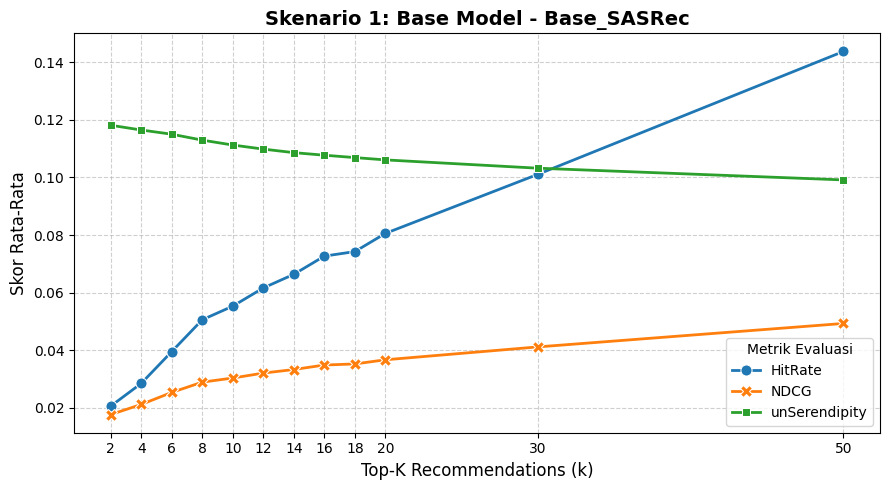

In [79]:
plot_single_model_metrics(df_master_all_users, model_name='Base_SASRec', title='Skenario 1: Base Model')

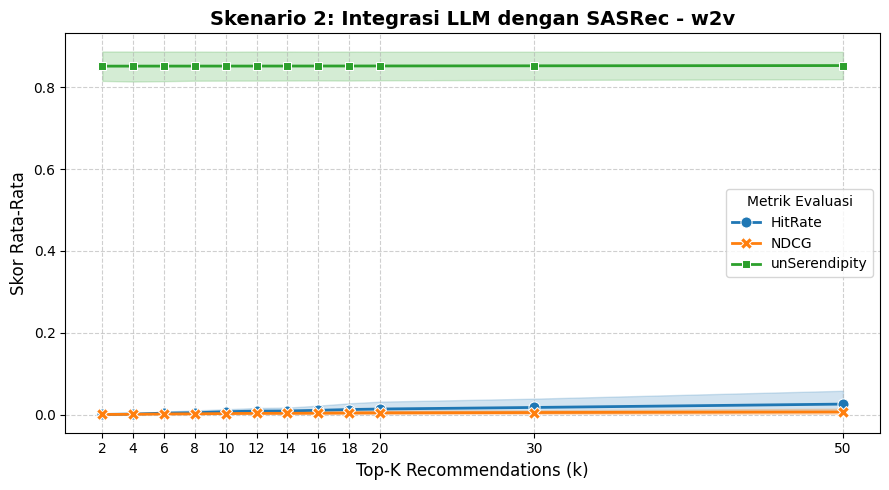

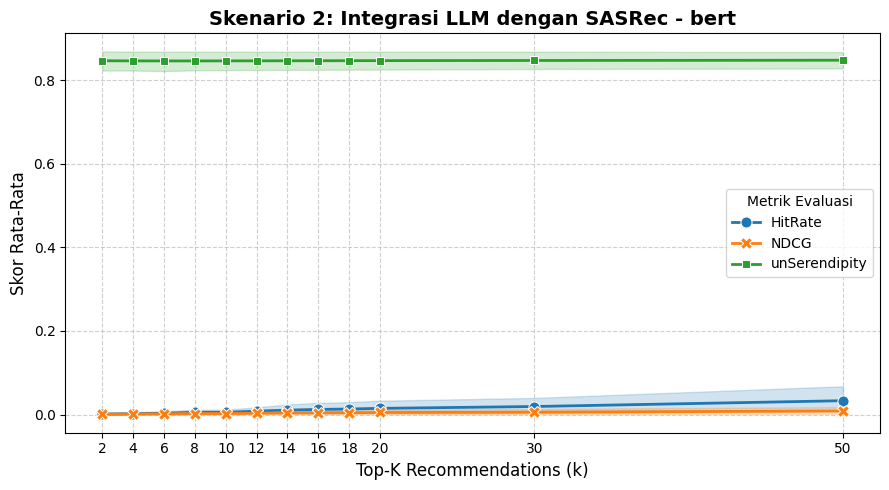

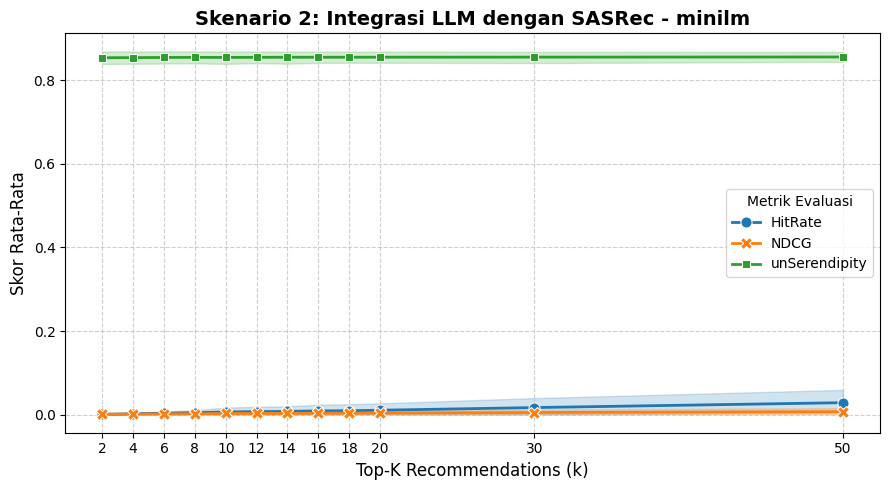

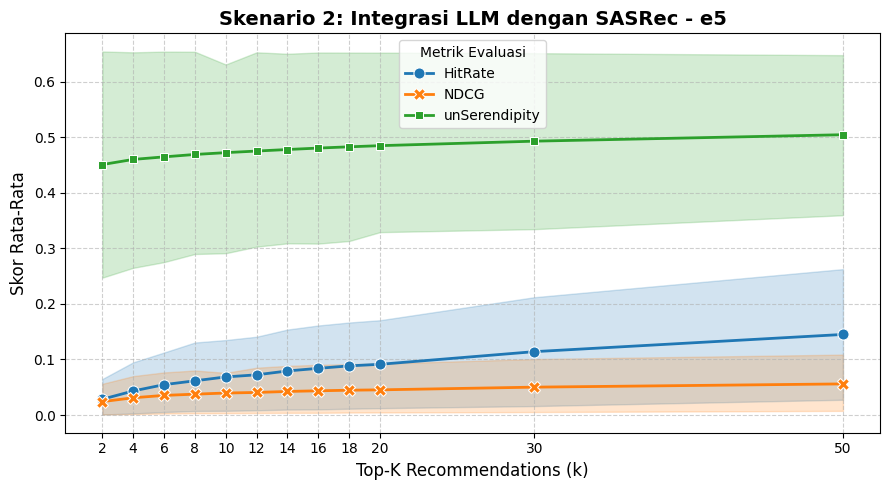

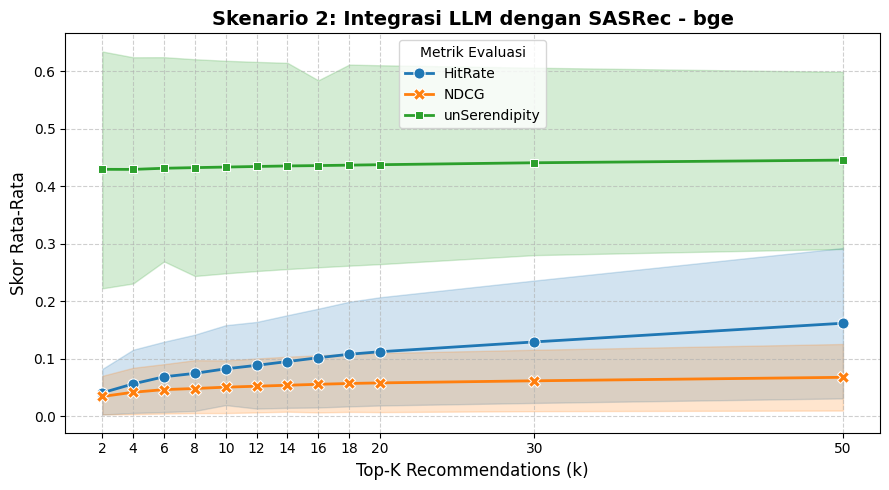

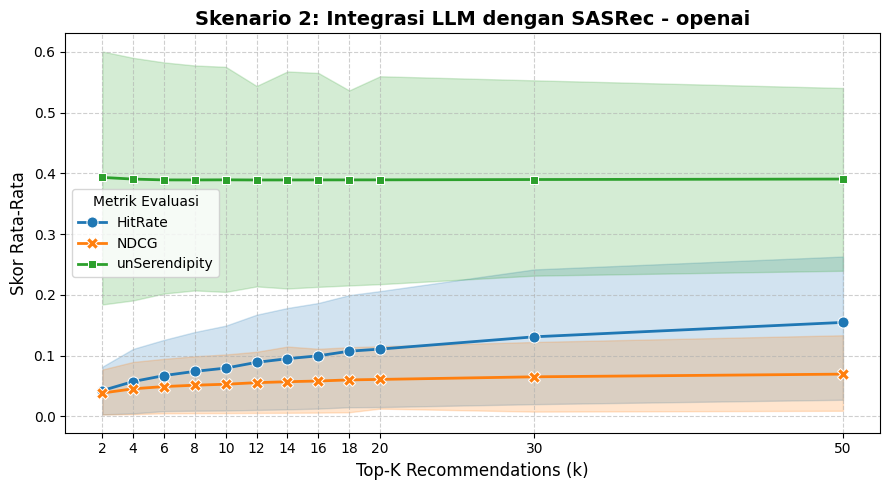

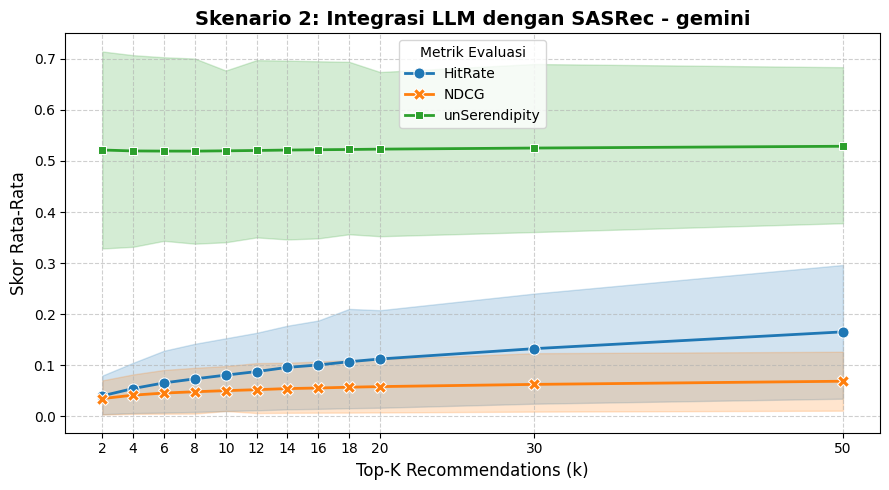

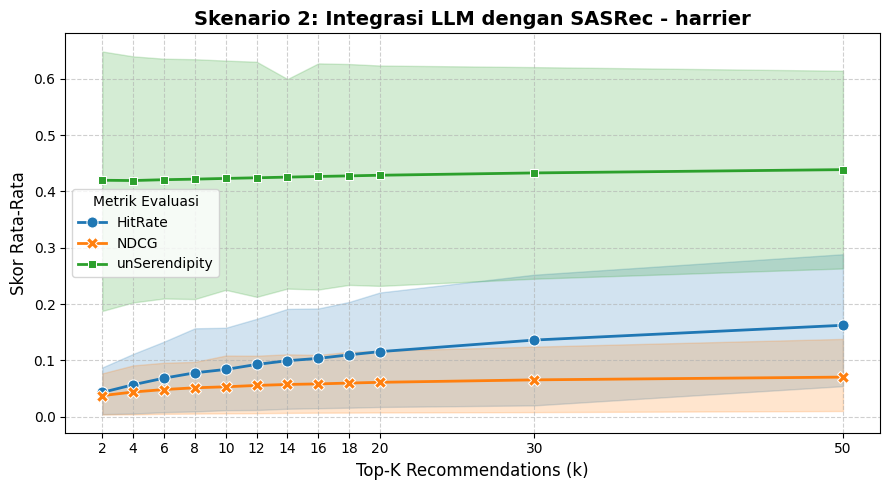

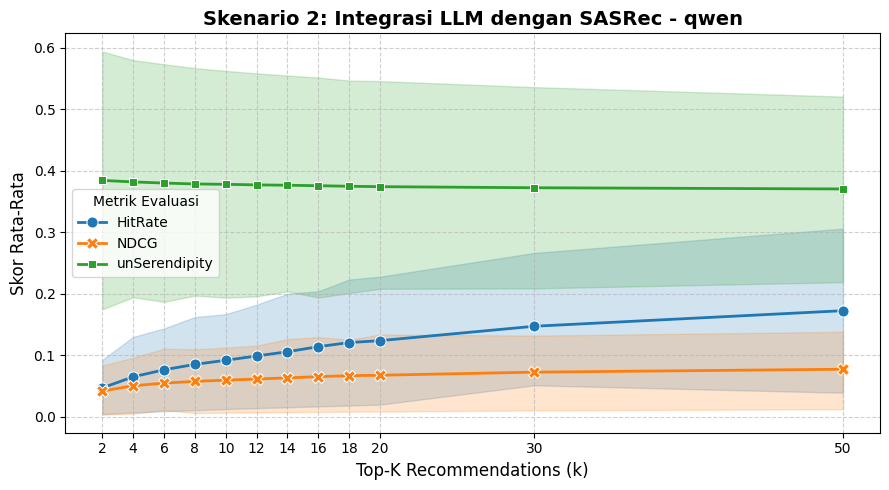

In [80]:
sasrecllm_models = [m for m in df_master_all_users['Model'].unique() if m != 'Base_SASRec']

for model_name in sasrecllm_models:
    plot_single_model_metrics(df_master_all_users, model_name=model_name, title='Skenario 2: Integrasi LLM dengan SASRec')

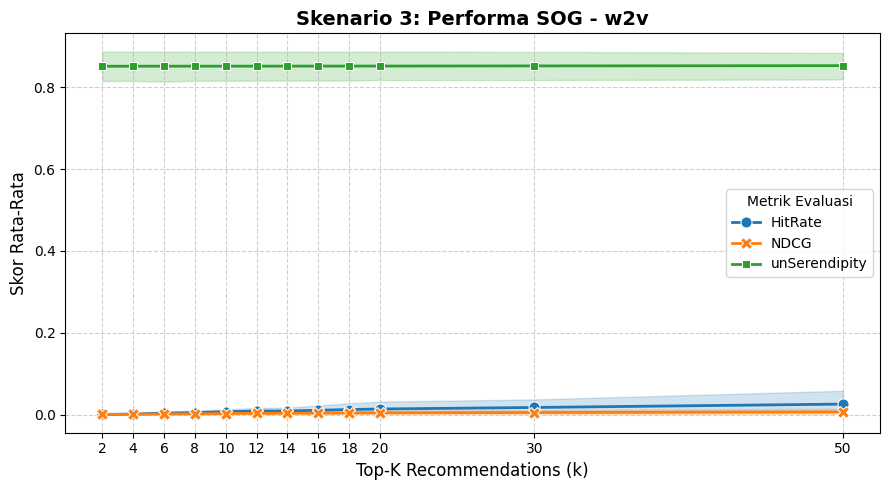

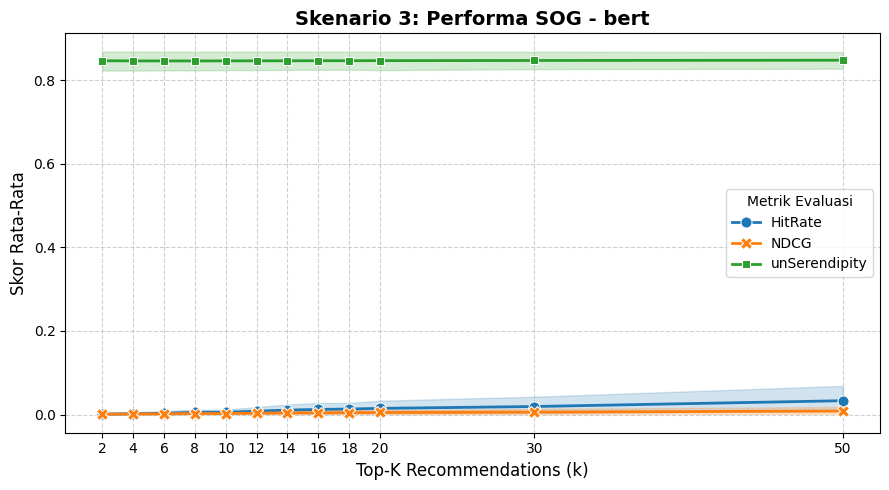

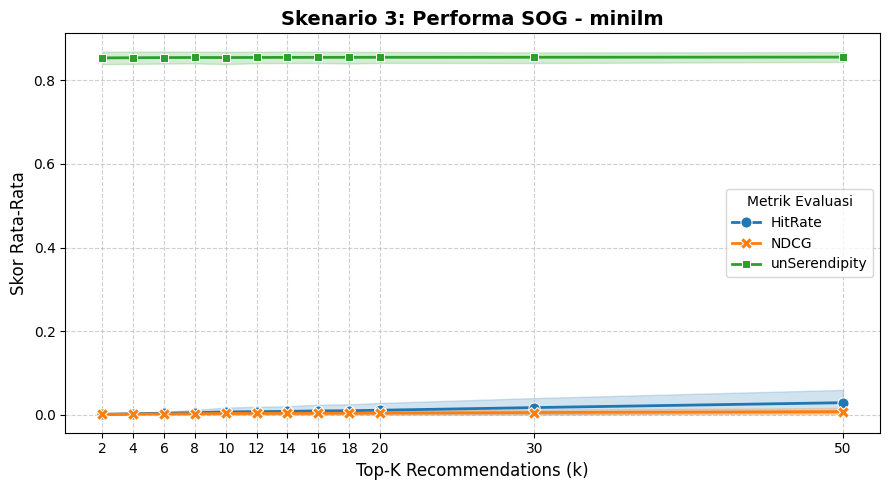

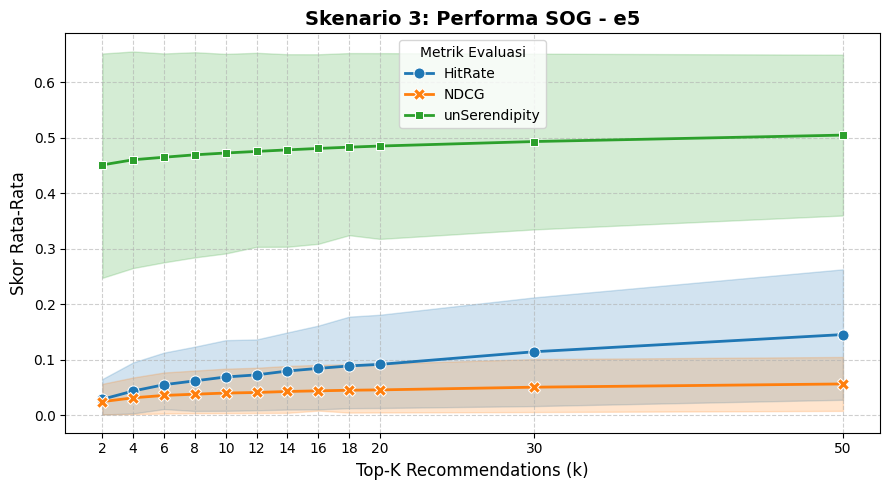

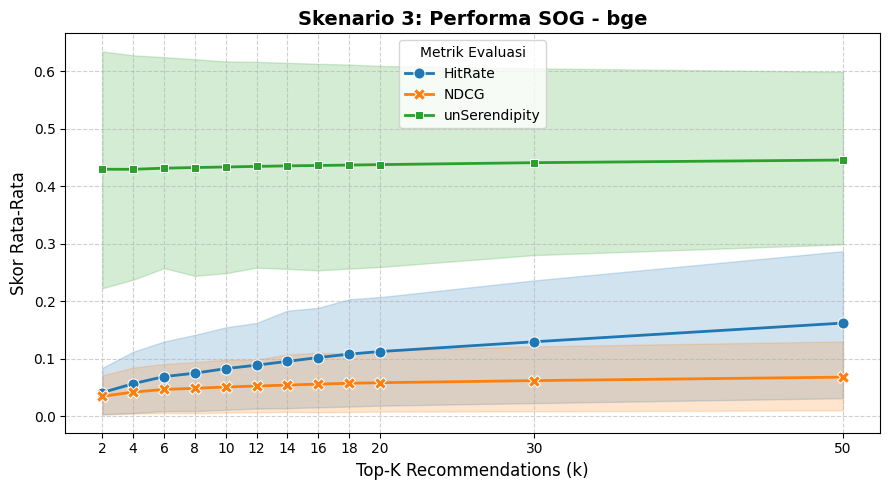

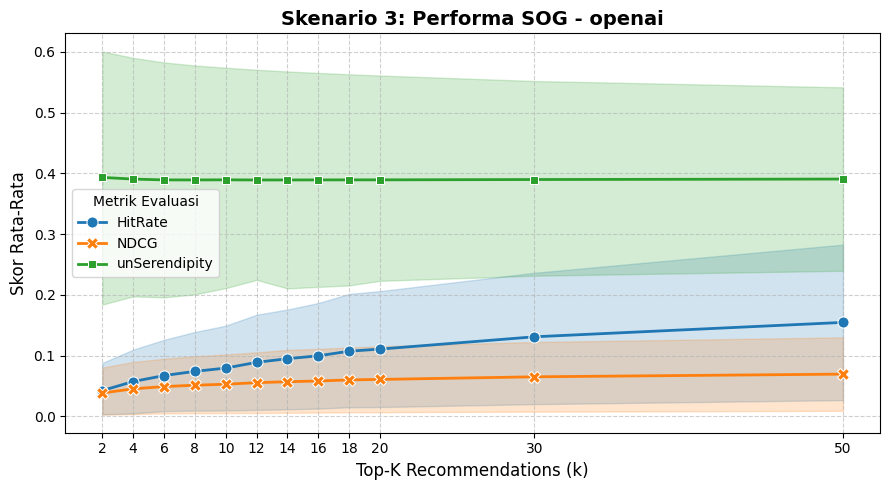

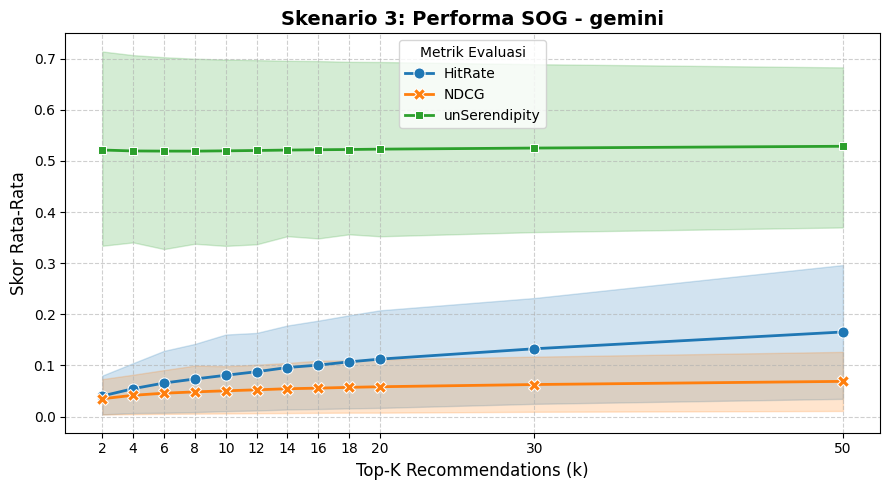

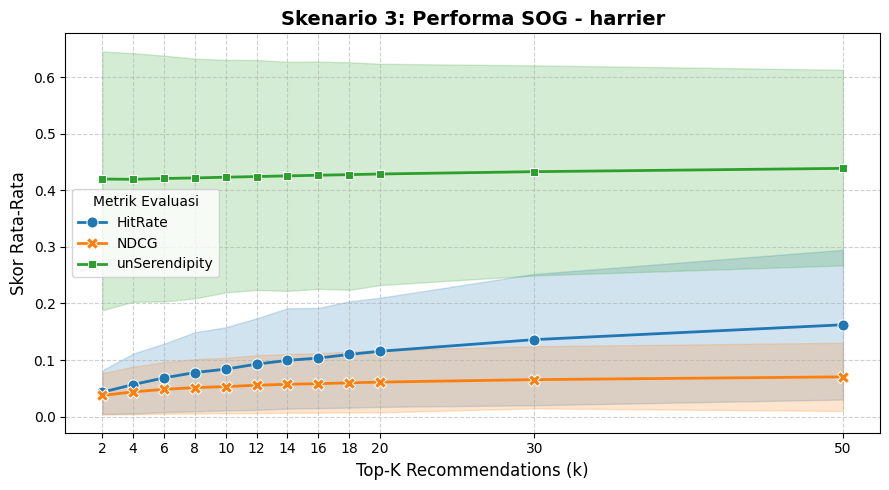

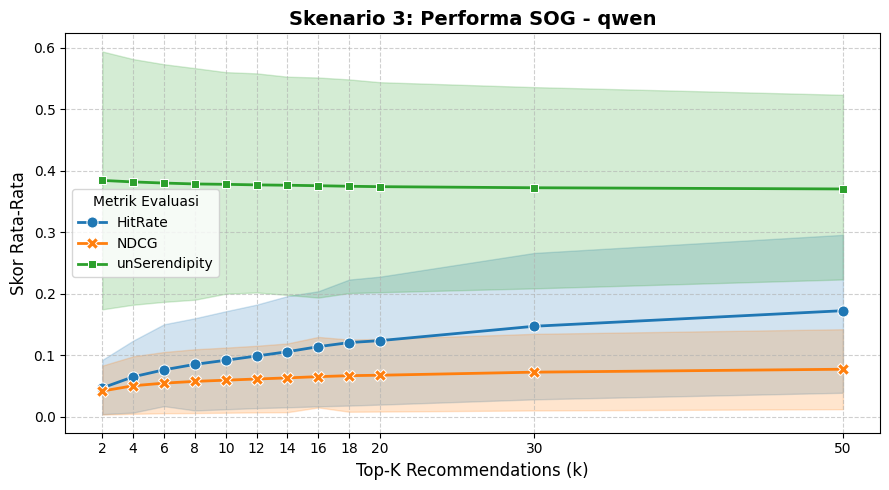

In [81]:
sog_models = [m for m in df_master_all_users['Model'].unique() if m != 'Base_SASRec']

for model_name in sog_models:
    plot_single_model_metrics(df_master_all_users, model_name=model_name, title='Skenario 3: Performa SOG')

In [82]:
def plot_metric_competition(df, metric_to_plot, title):
    plt.figure(figsize=(10, 6))
    
    sns.lineplot(
        data=df, 
        x='k', y=metric_to_plot, 
        hue='Model', 
        style='Model', 
        markers=True, dashes=False, linewidth=2, markersize=8
    )
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Top-K Recommendations (k)', fontsize=12)
    plt.ylabel(f'Skor {metric_to_plot}', fontsize=12)
    plt.xticks(df['k'].unique())
    
    # Pindahkan legenda ke luar grafik agar tidak menabrak garis
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Variasi Model")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

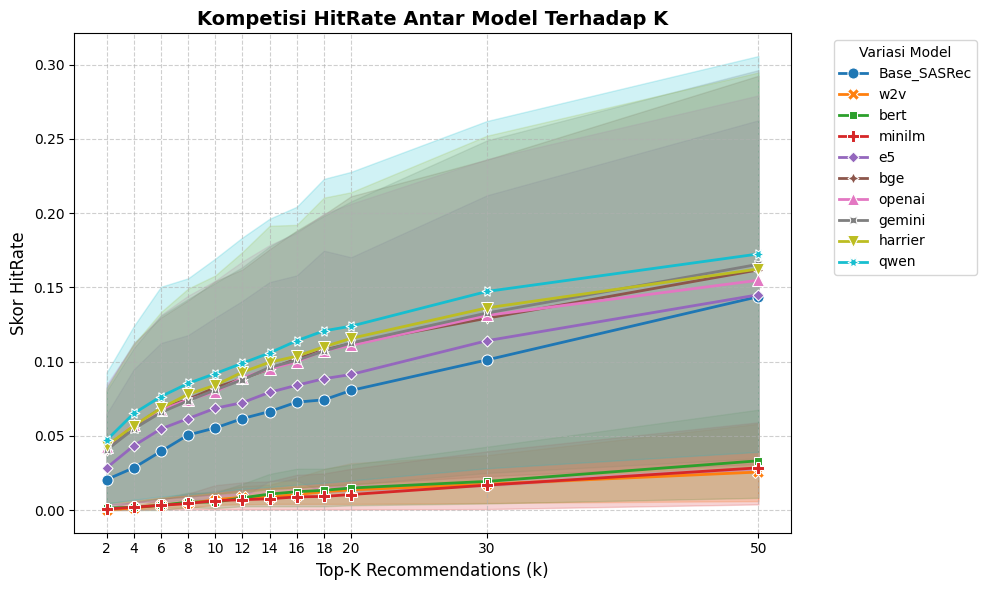

In [83]:
plot_metric_competition(df_master_all_users, 'HitRate', 'Kompetisi HitRate Antar Model Terhadap K')

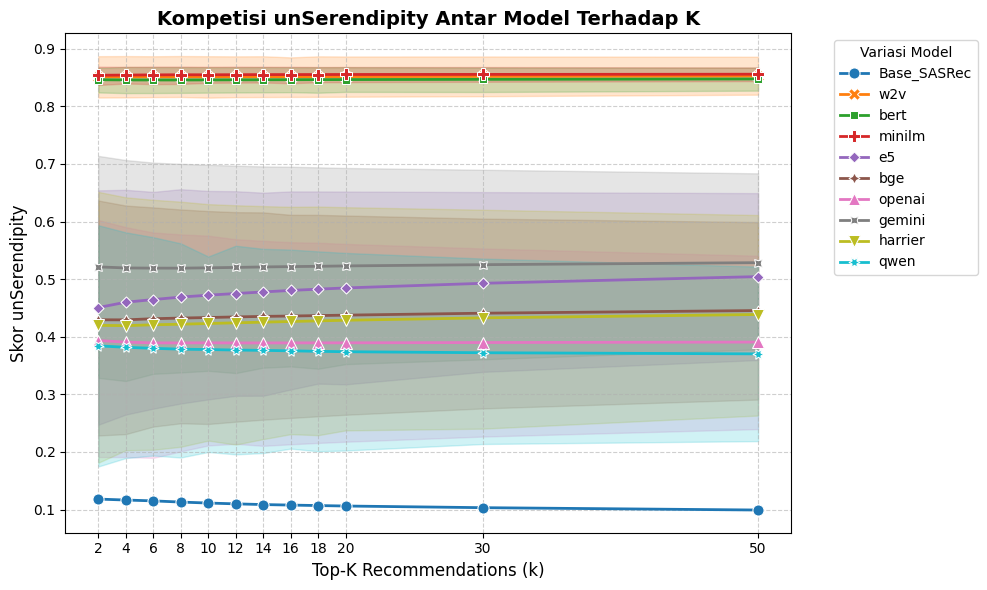

In [84]:
plot_metric_competition(df_master_all_users, 'unSerendipity', 'Kompetisi unSerendipity Antar Model Terhadap K')

In [85]:
def plot_comparison_at_k(df, k_val=10):
    # Filter data khusus untuk k yang diinginkan
    df_k = df[df['k'] == k_val].copy()
    
    if df_k.empty:
        print(f"Data untuk K={k_val} tidak ditemukan!")
        return
        
    # Melt dataframe agar bisa di-plot secara grouped bar
    df_melt = df_k.melt(
        id_vars=['Model'], 
        value_vars=['HitRate', 'NDCG', 'unSerendipity'], 
        var_name='Metrik', 
        value_name='Skor'
    )
    
    plt.figure(figsize=(14, 6))
    
    barplot = sns.barplot(
        data=df_melt, 
        x='Model', y='Skor', hue='Metrik',
        palette=['#1f77b4', '#ff7f0e', '#2ca02c']
    )
    
    plt.title(f'Perbandingan Seluruh Metrik Antar Model pada Top-{k_val}', fontsize=16, fontweight='bold')
    plt.xlabel('Varian Model', fontsize=12)
    plt.ylabel('Skor Rata-Rata', fontsize=12)
    
    # Putar label sumbu X agar nama model panjang bisa terbaca
    plt.xticks(rotation=30, ha='right')
    
    # Tambahkan angka di atas setiap batang
    for p in barplot.patches:
        val = p.get_height()
        if val > 0: # Cek jika nilai tidak NaN/0
            barplot.annotate(f'{val:.4f}', 
                            (p.get_x() + p.get_width() / 2., val), 
                            ha = 'center', va = 'center', 
                            xytext = (0, 8), 
                            textcoords = 'offset points',
                            fontsize=8, rotation=90) # Angka dirotasi agar tidak saling bertumpuk

    plt.legend(title='Metrik')
    plt.tight_layout()
    plt.show()

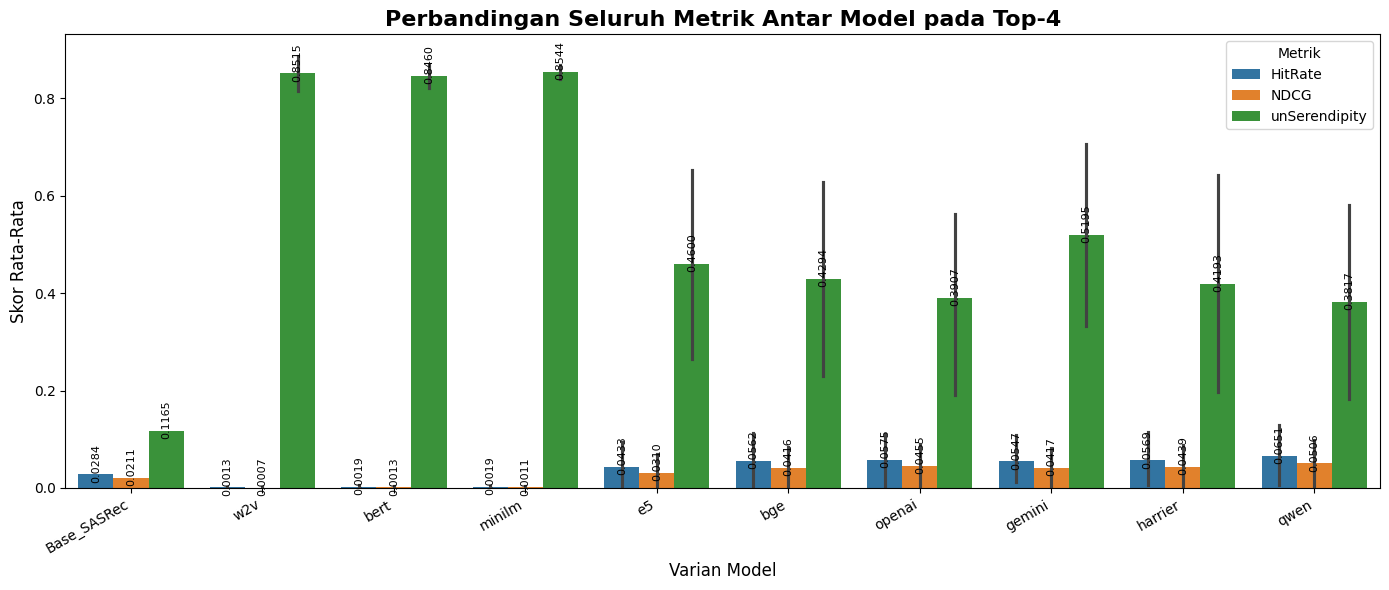

In [86]:
plot_comparison_at_k(df_master_all_users, k_val=4)

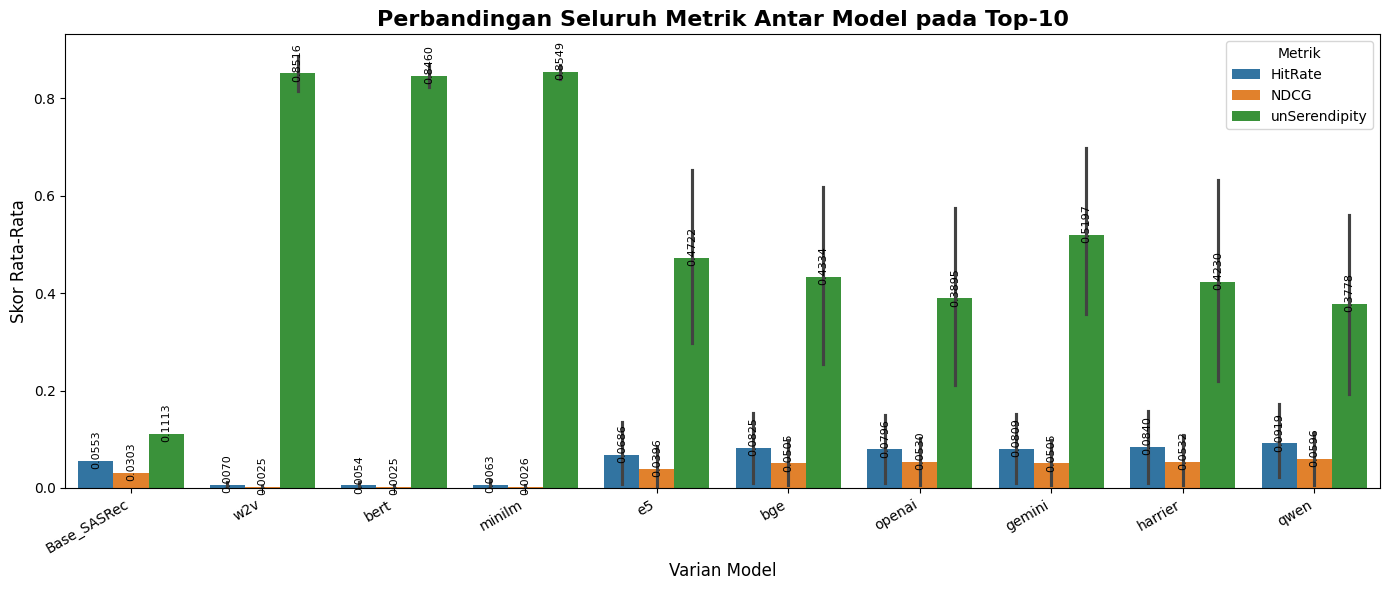

In [87]:
plot_comparison_at_k(df_master_all_users, k_val=10)

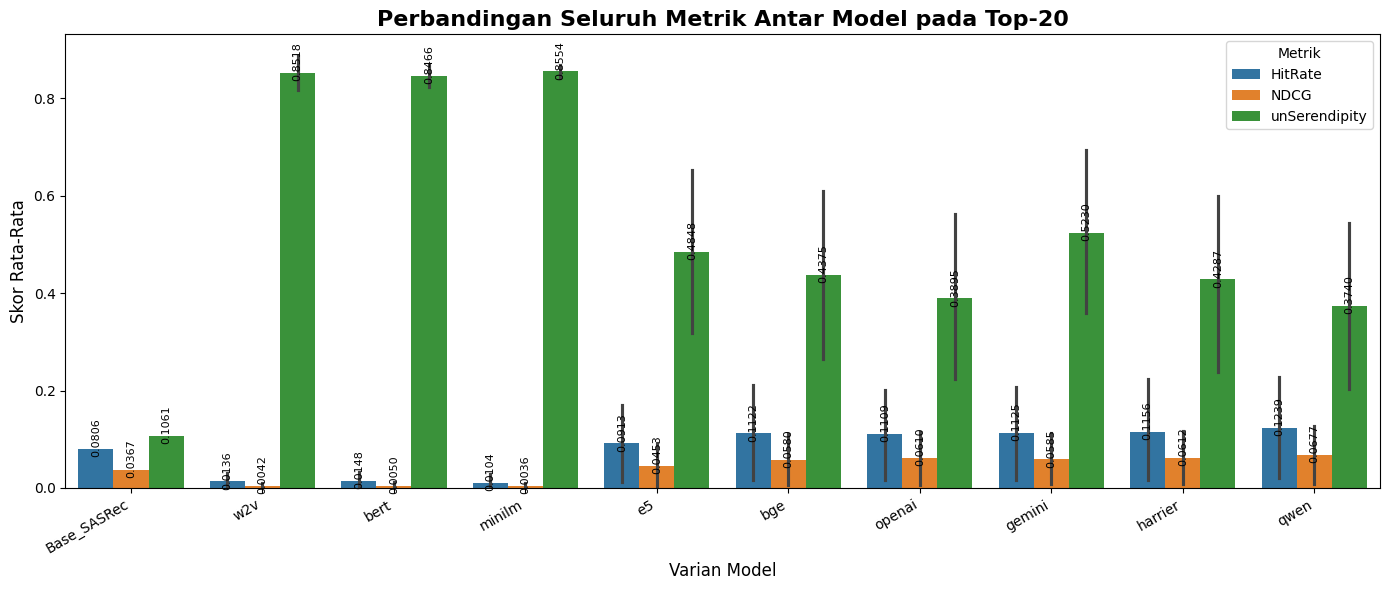

In [88]:
plot_comparison_at_k(df_master_all_users, k_val=20)

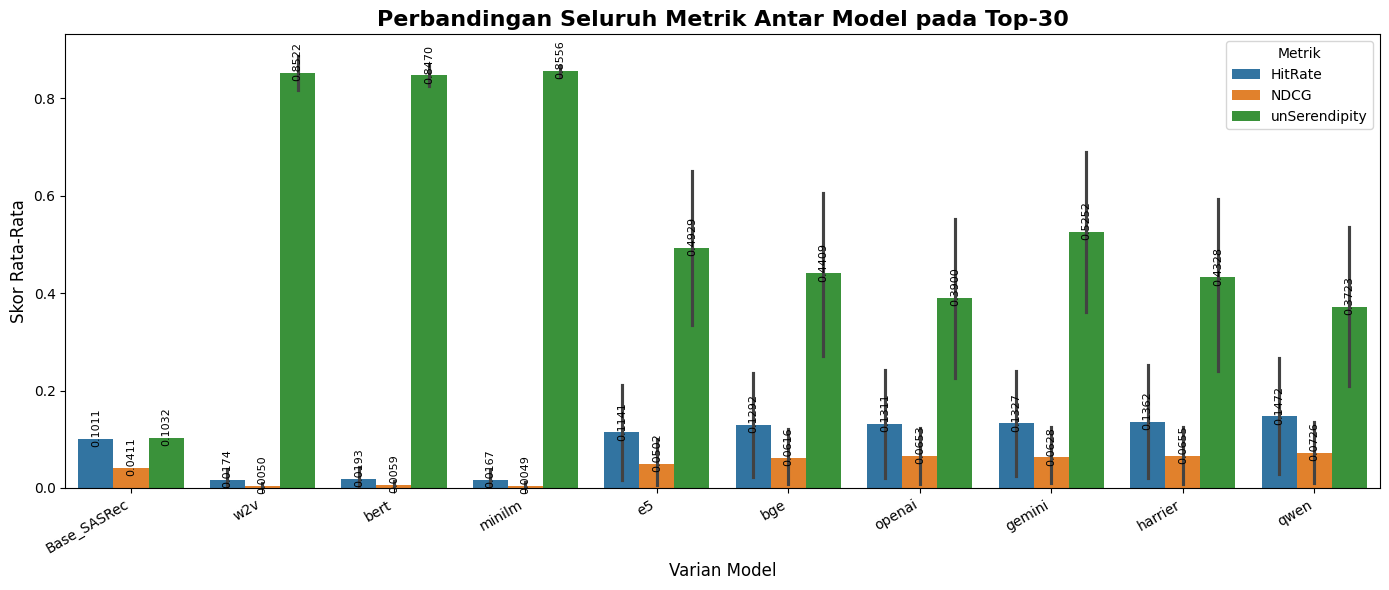

In [89]:
plot_comparison_at_k(df_master_all_users, k_val=30)

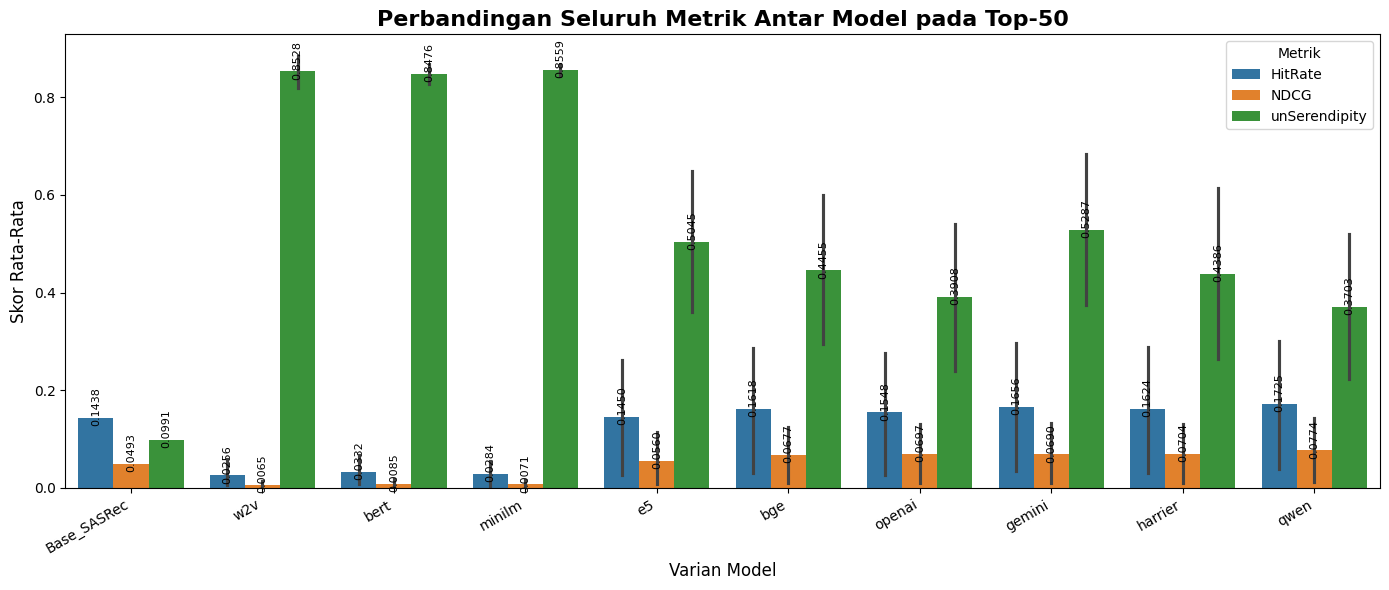

In [90]:
plot_comparison_at_k(df_master_all_users, k_val=50)

In [91]:
def plot_tradeoff_scatter_2(df, k_val=10, user_type='all'):
    df = df.copy() 
    
    plt.figure(figsize=(10, 6))
    
    if 'Base_Model' not in df.columns:
        df['Base_Model'] = df['Model'].apply(lambda x: 'Base_SASRec' if 'Base' in x else x.split('_')[0])
                
    # Filter data
    if 'User_Type' in df.columns:
        df_k = df[(df['User_Type'] == user_type) & (df['k'] == k_val)].copy()
    else:
        df_k = df[df['k'] == k_val].copy()
        
    if df_k.empty:
        print(f"Data tidak ditemukan untuk k={k_val} and user_type='{user_type}'!")
        return

    # Scatter Plot
    scatter = sns.scatterplot(
        data=df_k,
        x='unSerendipity',
        y='HitRate',
        hue='Model',
        style='Base_Model',
        s=200,
        palette='tab20',
        alpha=0.8,
    )
    
    # Text Labels
    for i in range(df_k.shape[0]):
        plt.text(
            df_k['unSerendipity'].iloc[i],
            df_k['HitRate'].iloc[i] + 0.01,
            df_k['Model'].iloc[i],
            horizontalalignment='center',
            fontsize=8, color='black', weight='semibold'
        )

    # FIX: Set the bounds to 0-1
    plt.xlim(0, 1)
    plt.ylim(0, 0.4)

    plt.title(f'Trade-off Frontier: HitRate vs unSerendipity (Top-{k_val}) {"Semua User" if user_type == "all" else user_type}', fontsize=14, fontweight='bold')
    plt.xlabel('unSerendipity (Semakin KIRI Semakin Baik / Serendipity Tinggi)', fontsize=12, color='darkred')
    plt.ylabel('HitRate (Semakin ATAS Semakin Baik / Akurat)', fontsize=12, color='darkgreen')
    
    plt.annotate('Balanced Area\n(Akurat & Beragam)', 
                xy=(0.05, 0.9), xycoords='axes fraction',
                fontsize=10, color='green', weight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="lightgreen", ec="green", alpha=0.3))

    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout() 
    plt.show()

In [92]:
scenario_2 = df_master[(df_master['Train_Scenario'] == 2)]

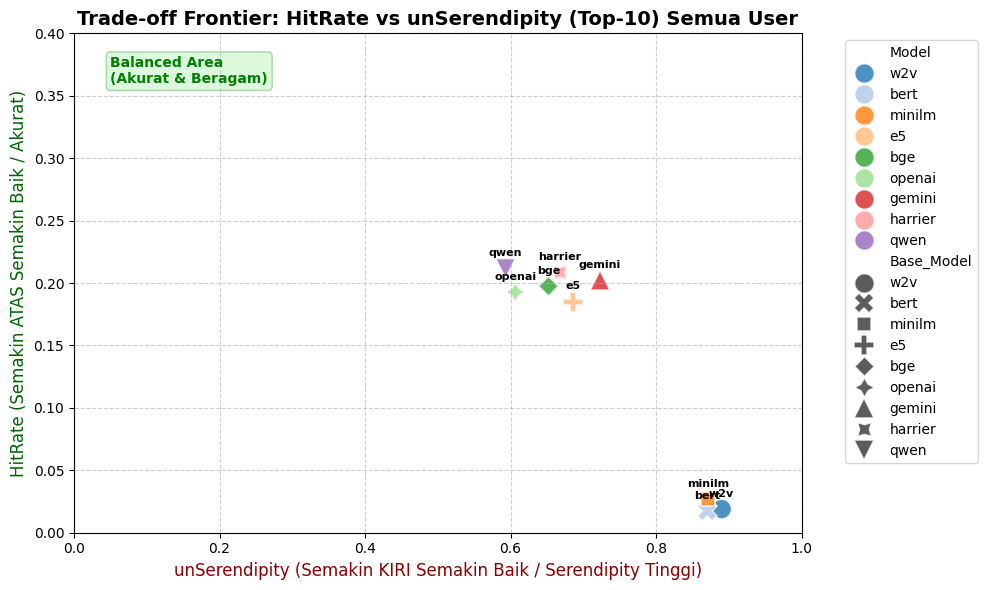

In [93]:
plot_tradeoff_scatter_2(scenario_2, k_val=10, user_type='all')

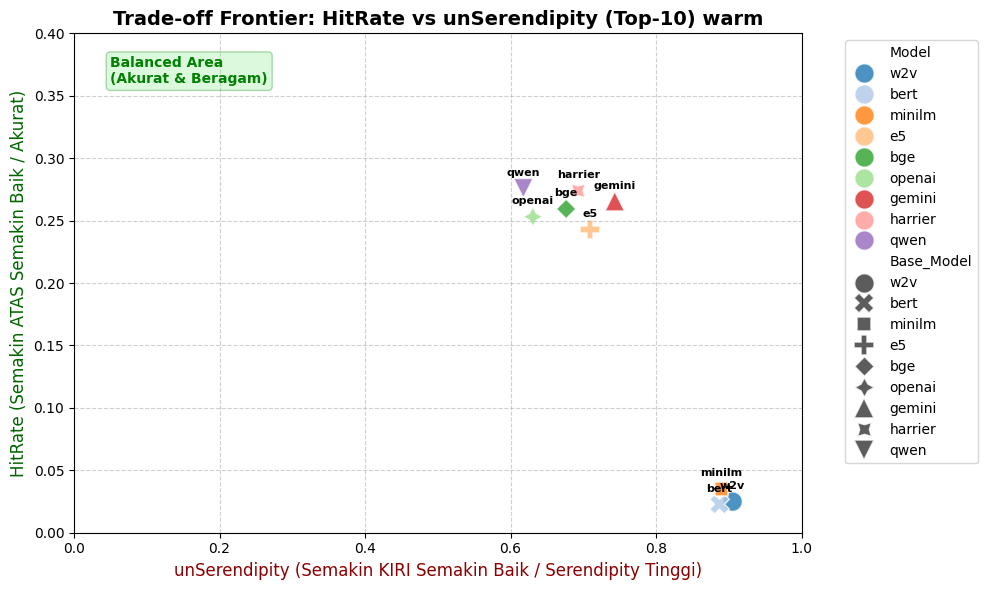

In [94]:
plot_tradeoff_scatter_2(scenario_2, k_val=10, user_type='warm')

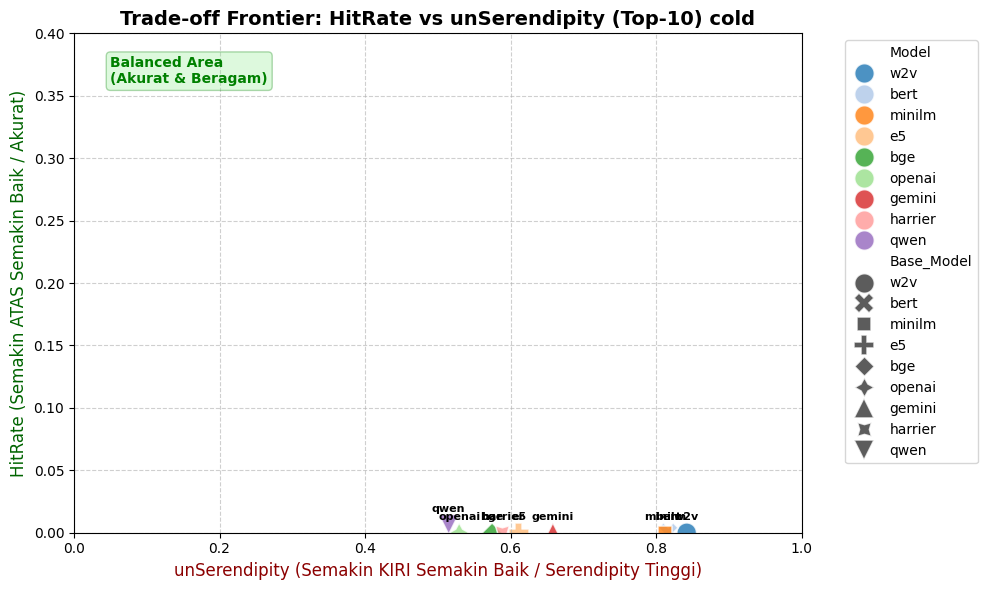

In [95]:
plot_tradeoff_scatter_2(scenario_2, k_val=10, user_type='cold')

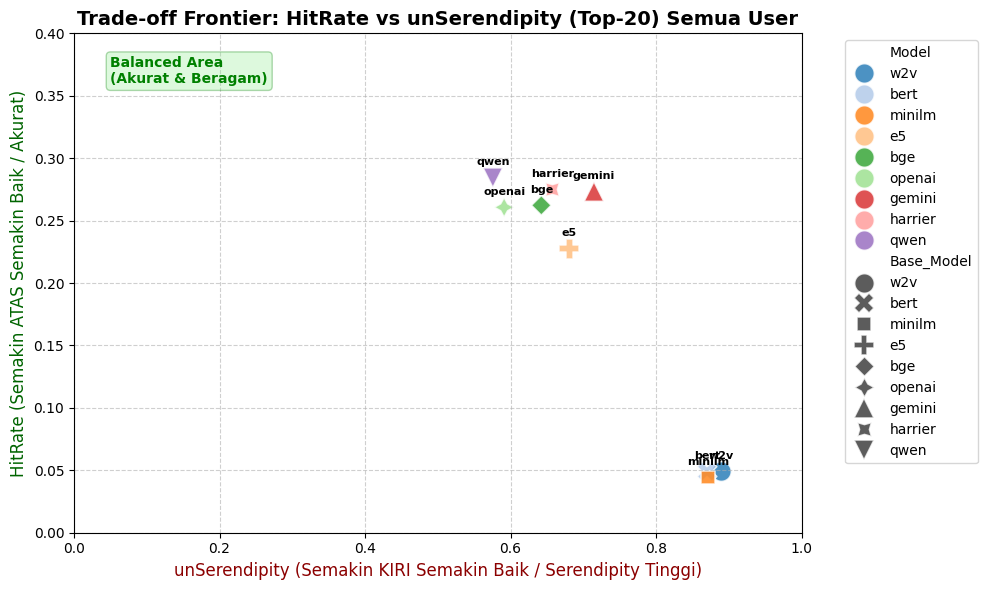

In [96]:
plot_tradeoff_scatter_2(scenario_2, k_val=20, user_type='all')

In [97]:
def plot_tradeoff_scatter_3(df, k_val=10, user_type='all'):
    plt.figure(figsize=(10, 6))
    
    # Buat kolom Base_Model secara otomatis jika belum ada
    if 'Base_Model' not in df.columns:
        df['Base_Model'] = df['Model'].apply(lambda x: 'Base_SASRec' if 'Base' in x else x.split('_')[0])
        
    # Filter data
    if 'User_Type' in df.columns:
        df_k = df[(df['User_Type'] == user_type) & (df['k'] == k_val)].copy()
    else:
        df_k = df[df['k'] == k_val].copy()
        
    if df_k.empty:
        print(f"Data tidak ditemukan untuk k={k_val} dan user_type='{user_type}'!")
        return

    # Scatter Plot
    scatter = sns.scatterplot(
        data=df_k,
        x='unSerendipity',
        y='HitRate',
        hue='Model',
        style='Base_Model',
        s=200,
        palette='tab20',
        alpha=0.8
    )
    
    for i in range(df_k.shape[0]):
        label_text = df_k['Weight_Profile'].iloc[i]
        
        plt.text(
            df_k['unSerendipity'].iloc[i],
            df_k['HitRate'].iloc[i] + 0.0015,
            label_text,
            horizontalalignment='center',
            fontsize=8, color='black', weight='semibold'
        )

    plt.title(f'Trade-off Frontier: HitRate vs unSerendipity (Top-{k_val})', fontsize=14, fontweight='bold')
    plt.xlabel('unSerendipity (Semakin KIRI Semakin Baik / Serendipity Tinggi)', fontsize=12, color='darkred')
    plt.ylabel('HitRate (Semakin ATAS Semakin Baik / Akurat)', fontsize=12, color='darkgreen')
    
    # Tambahkan teks penjelasan Sweet Spot di dalam grafik
    plt.annotate('Balanced Area\n(Akurat & Beragam)', 
                xy=(0.05, 0.9), xycoords='axes fraction',
                fontsize=10, color='green', weight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="lightgreen", ec="green", alpha=0.3))

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [98]:
scenario_3 = df_master[(df_master['Train_Scenario'] == 3)]

/tmp/ipykernel_23/597956727.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Base_Model'] = df['Model'].apply(lambda x: 'Base_SASRec' if 'Base' in x else x.split('_')[0])


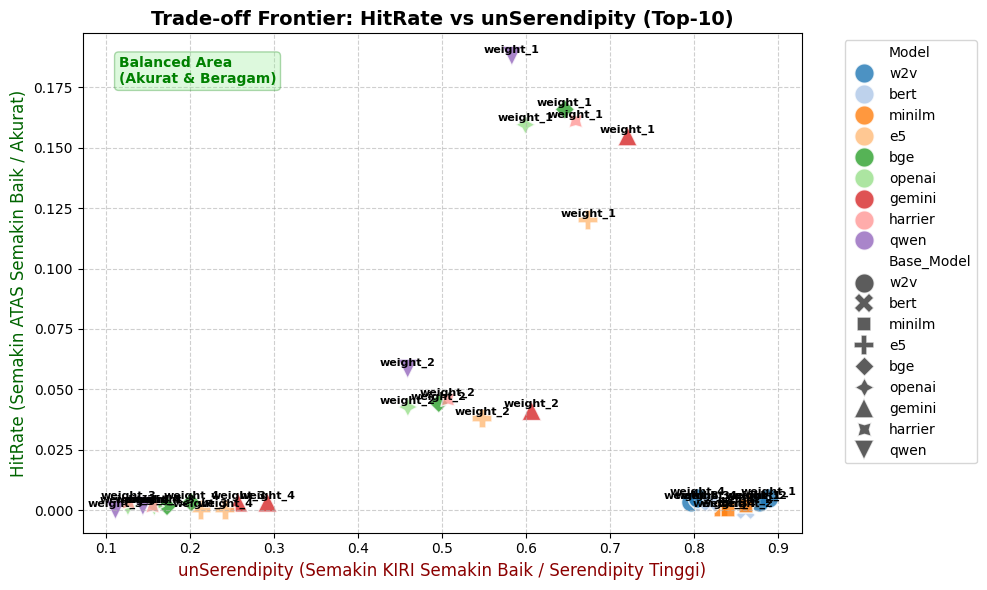

In [99]:
plot_tradeoff_scatter_3(scenario_3, k_val=10, user_type='all')

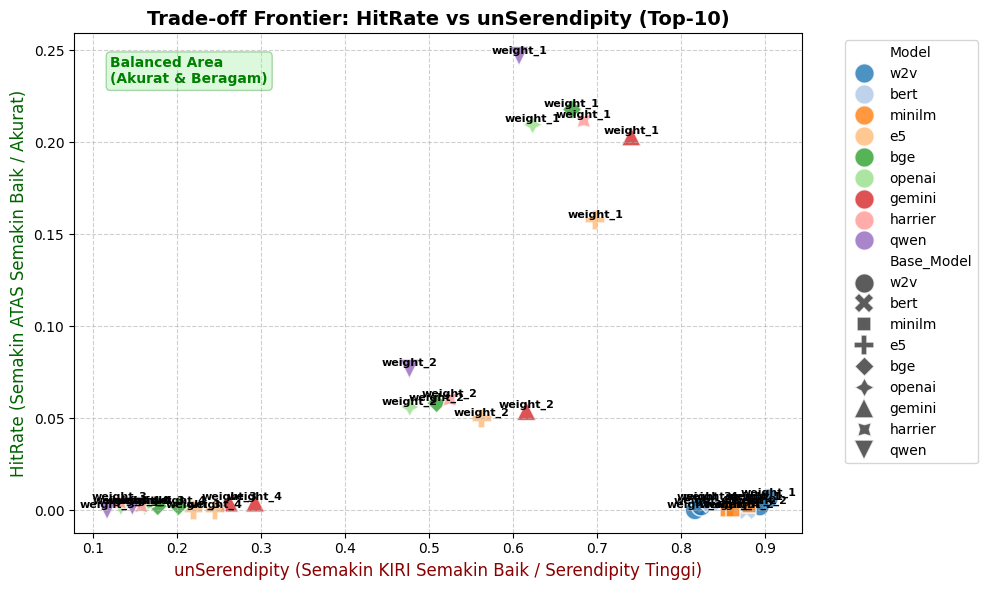

In [100]:
plot_tradeoff_scatter_3(scenario_3, k_val=10, user_type='warm')

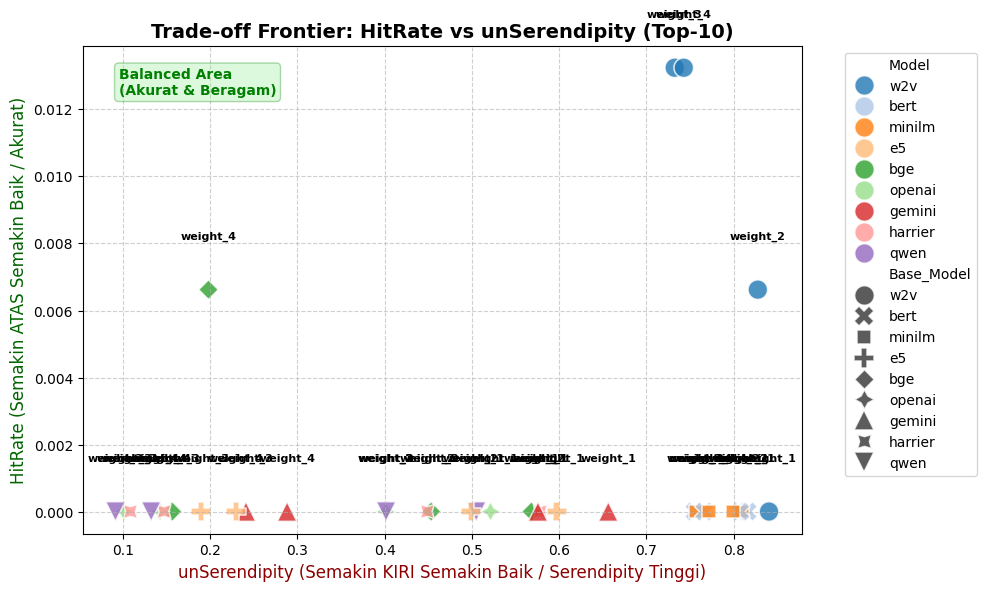

In [101]:
plot_tradeoff_scatter_3(scenario_3, k_val=10, user_type='cold')

In [102]:
def plot_cold_vs_warm(df_full, metric='HitRate', k_val=10):
    # Filter data hanya untuk Cold dan Warm, pada nilai K tertentu
    df_cw = df_full[(df_full['k'] == k_val) & (df_full['User_Type'].isin(['warm', 'cold']))].copy()
    
    # Jika tidak ada data cold/warm, hentikan
    if df_cw.empty:
        print("Data Cold/Warm tidak ditemukan!")
        return
        
    plt.figure(figsize=(12, 6))
    
    # Gunakan barplot terkelompok
    barplot = sns.barplot(
        data=df_cw,
        x='Model',
        y=metric,
        hue='User_Type',
        palette=['#f50c0c', '#4287f5'] # Warna (red, blue)
    )
    
    plt.title(f'Perbandingan {metric} pada Cold vs Warm Users (Top-{k_val})', fontsize=14, fontweight='bold')
    plt.xlabel('Varian Model', fontsize=12)
    plt.ylabel(f'Skor {metric}', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    # Tambahkan angka di atas bar
    for p in barplot.patches:
        height = p.get_height()
        if height > 0:
            barplot.annotate(f'{height:.3f}',
                            (p.get_x() + p.get_width() / 2., height),
                            ha = 'center', va = 'center',
                            xytext = (0, 8),
                            textcoords = 'offset points',
                            fontsize=8)

    plt.legend(title='Tipe Pengguna')
    plt.tight_layout()
    plt.show()

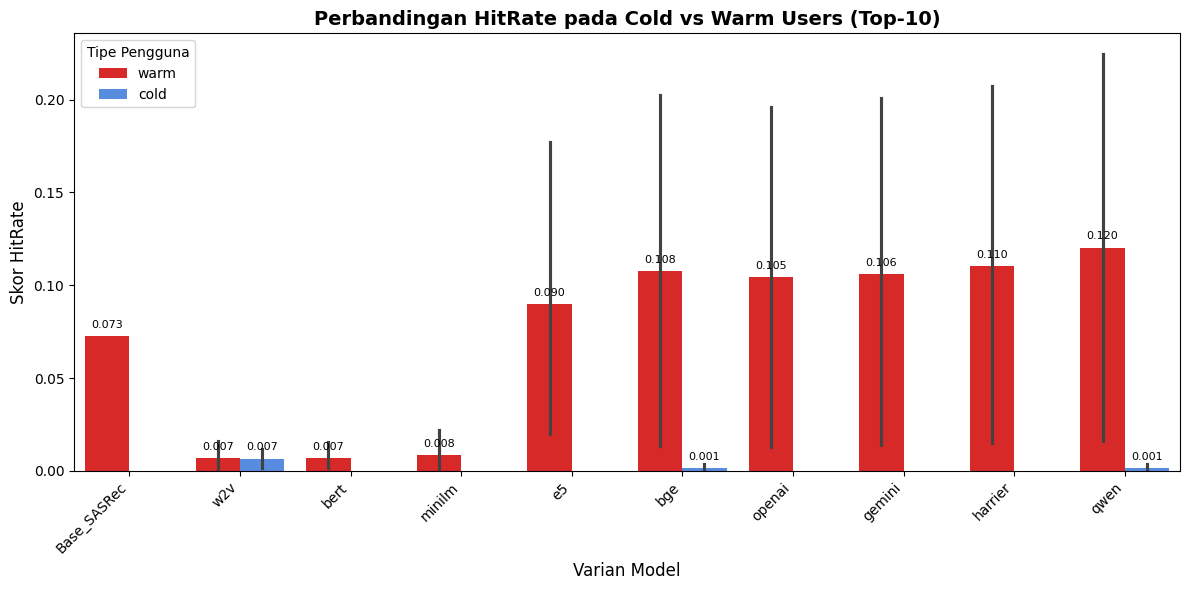

In [103]:
plot_cold_vs_warm(df_master, metric='HitRate', k_val=10)

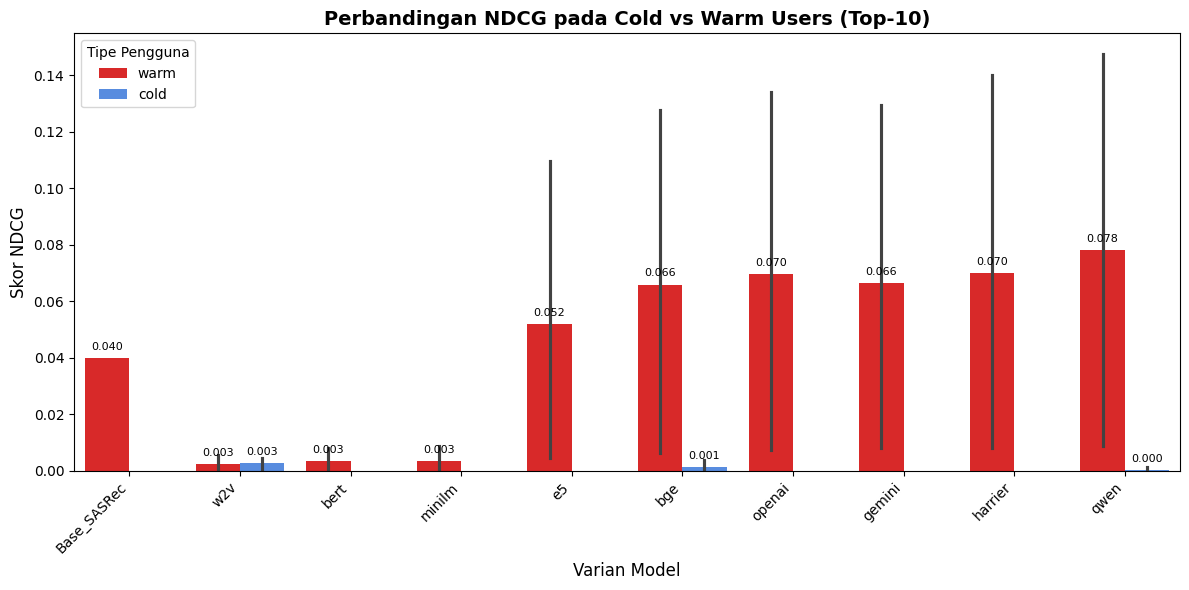

In [104]:
plot_cold_vs_warm(df_master, metric='NDCG', k_val=10)

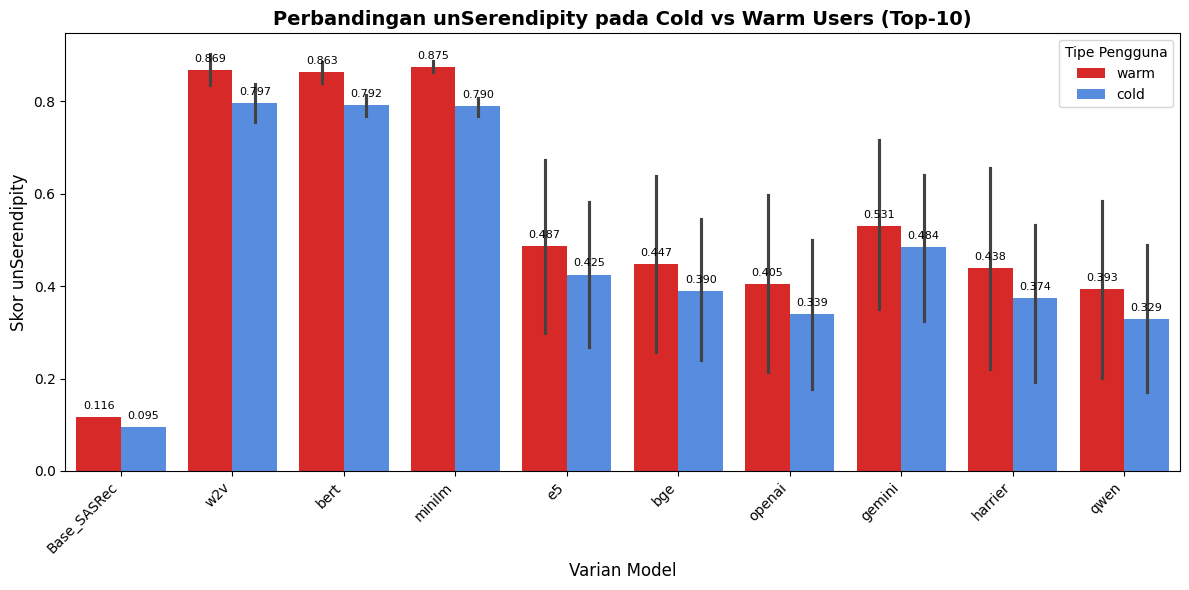

In [105]:
plot_cold_vs_warm(df_master, metric='unSerendipity', k_val=10)

In [106]:
def plot_delta_percentage(df, k_val=10, user_type='All'):
    df_k = df[df['k'] == k_val].copy()
    
    # Ambil nilai baseline (Base_SASRec)
    base_row = df_k[df_k['Model'] == 'Base_SASRec']
    if base_row.empty:
        print("Base model tidak ditemukan untuk perhitungan Delta!")
        return
        
    base_hit = base_row['HitRate'].values[0]
    base_ser = base_row['unSerendipity'].values[0]
    
    # Hitung persentase perubahan (Delta)
    df_k['Delta_HitRate (%)'] = ((df_k['HitRate'] - base_hit) / base_hit) * 100
    df_k['Delta_unSerendipity (%)'] = ((df_k['unSerendipity'] - base_ser) / base_ser) * 100
    
    # Buang Base model dari plot agar grafik fokus pada varian model saja
    df_plot = df_k[df_k['Model'] != 'Base_SASRec'].copy()
    
    # Melt untuk plotting
    df_melt = df_plot.melt(
        id_vars=['Model'], 
        value_vars=['Delta_HitRate (%)', 'Delta_unSerendipity (%)'],
        var_name='Metrik', value_name='Perubahan (%)'
    )
    
    plt.figure(figsize=(12, 6))
    
    # Bar plot (bisa bernilai negatif/positif)
    barplot = sns.barplot(
        data=df_melt,
        x='Model',
        y='Perubahan (%)',
        hue='Metrik',
        palette=['#d62728', '#2ca02c']
    )
    
    # Garis nol (Baseline)
    plt.axhline(0, color='black', linewidth=1.5, linestyle='--')
    
    plt.title(f'Persentase Perubahan Performa terhadap Model Base (Top-{k_val}) pada {user_type} Test Set', fontsize=14, fontweight='bold')
    plt.xlabel('Varian Model', fontsize=12)
    plt.ylabel('Perubahan (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    # Label nilai persen
    for p in barplot.patches:
        val = p.get_height()
        if not np.isnan(val):
            # Posisi teks: Jika positif di atas bar, jika negatif di bawah bar
            y_offset = 8 if val > 0 else -12
            barplot.annotate(f'{val:+.1f}%', 
                            (p.get_x() + p.get_width() / 2., val), 
                            ha = 'center', va = 'center', 
                            xytext = (0, y_offset), 
                            textcoords = 'offset points',
                            fontsize=8, fontweight='bold')

    plt.legend(title='Metrik vs Base')
    plt.tight_layout()
    plt.show()

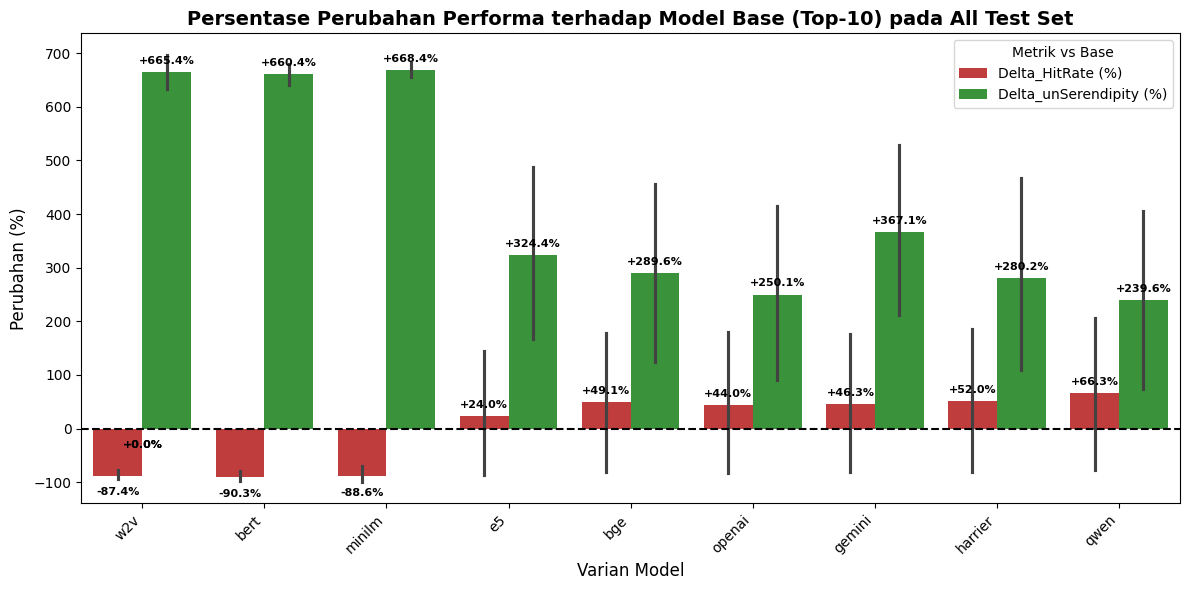

In [107]:
plot_delta_percentage(df_master_all_users, k_val=10, user_type="All")

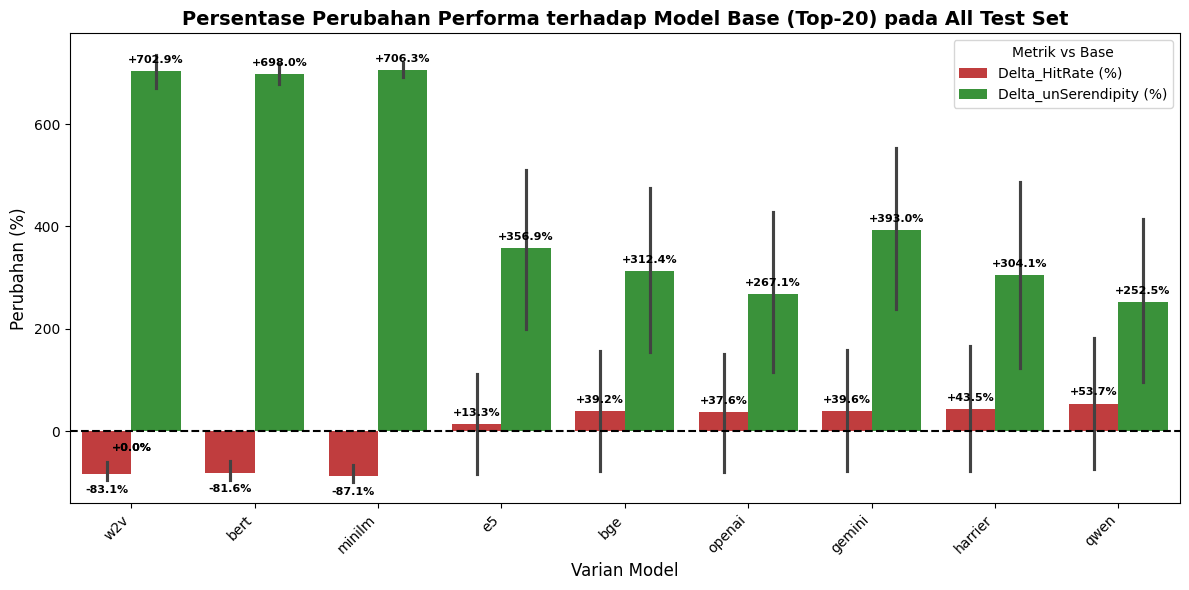

In [108]:
plot_delta_percentage(df_master_all_users, k_val=20)

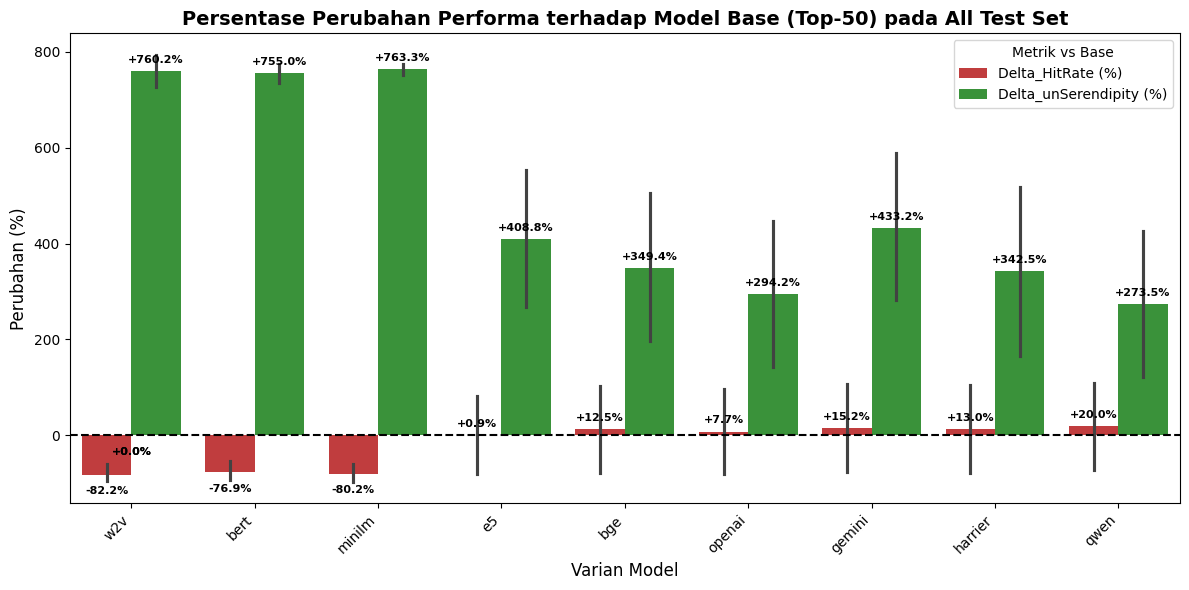

In [109]:
plot_delta_percentage(df_master_all_users, k_val=50)

In [110]:
df_warm_users = df_master[(df_master['User_Type'] == 'warm')].copy()
df_cold_users = df_master[(df_master['User_Type'] == 'cold')].copy()

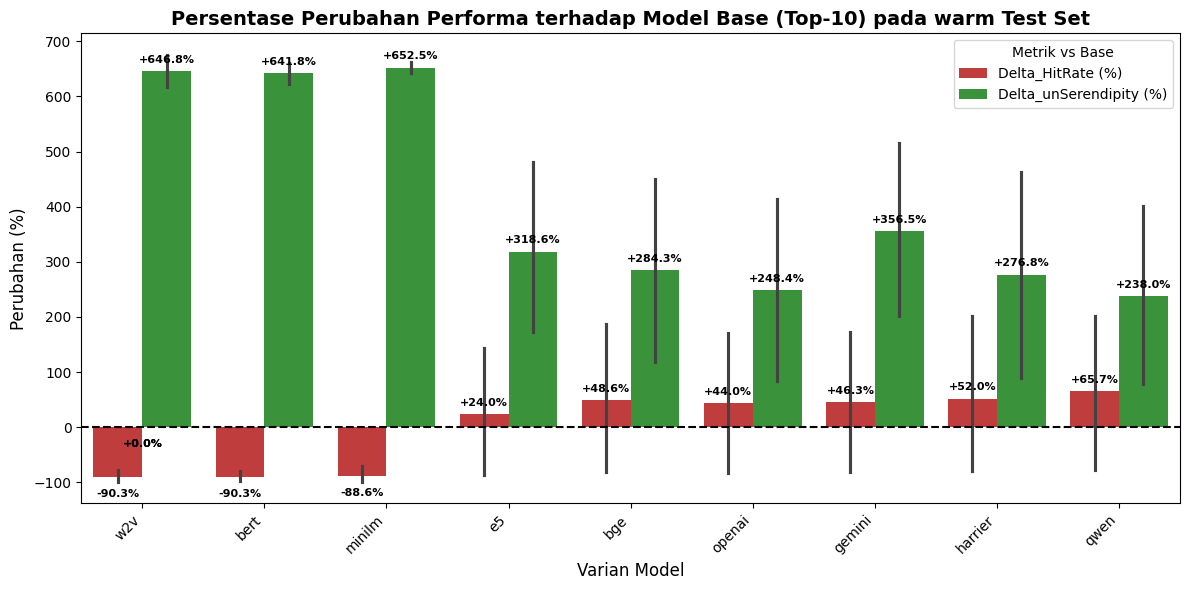

In [111]:
plot_delta_percentage(df_warm_users, k_val=10, user_type="warm")

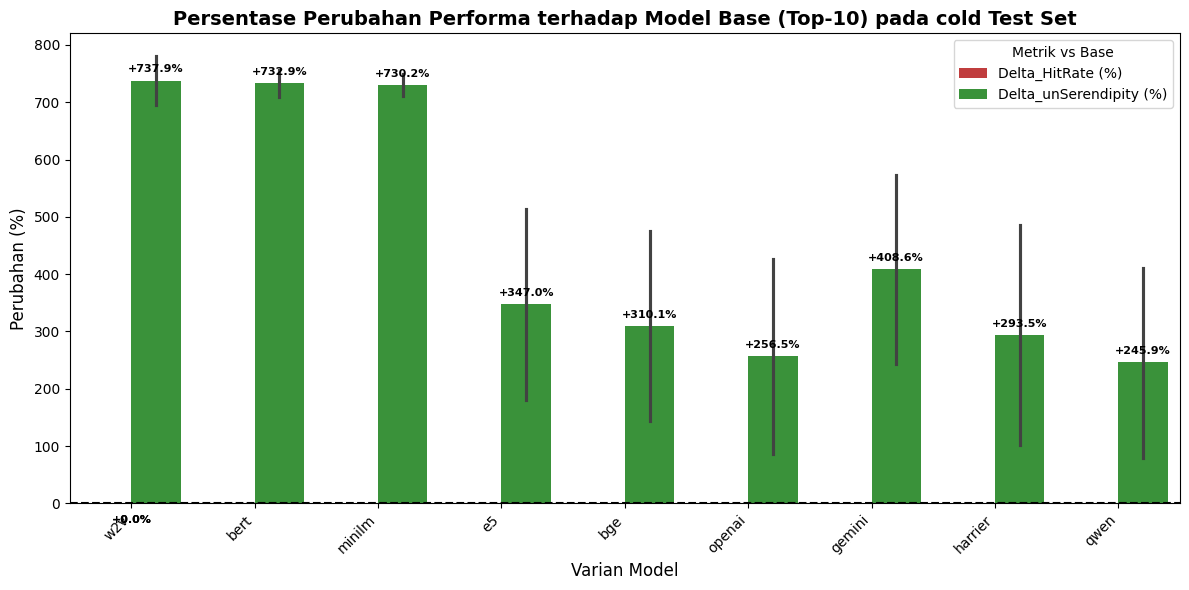

In [112]:
plot_delta_percentage(df_cold_users, k_val=10, user_type="cold")

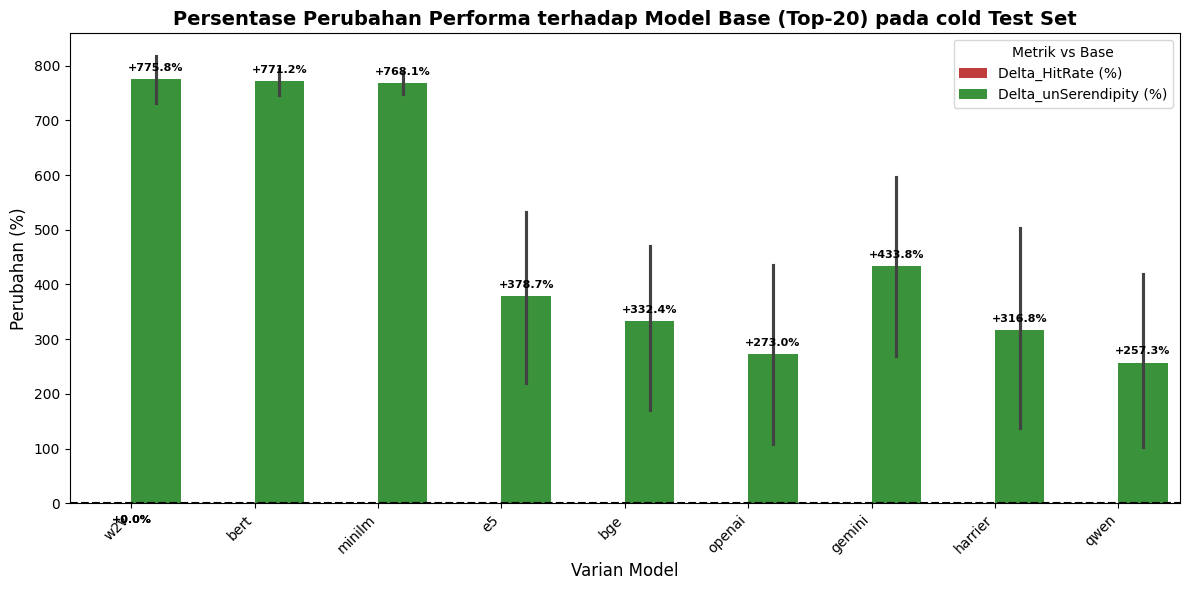

In [113]:
plot_delta_percentage(df_cold_users, k_val=20, user_type="cold")

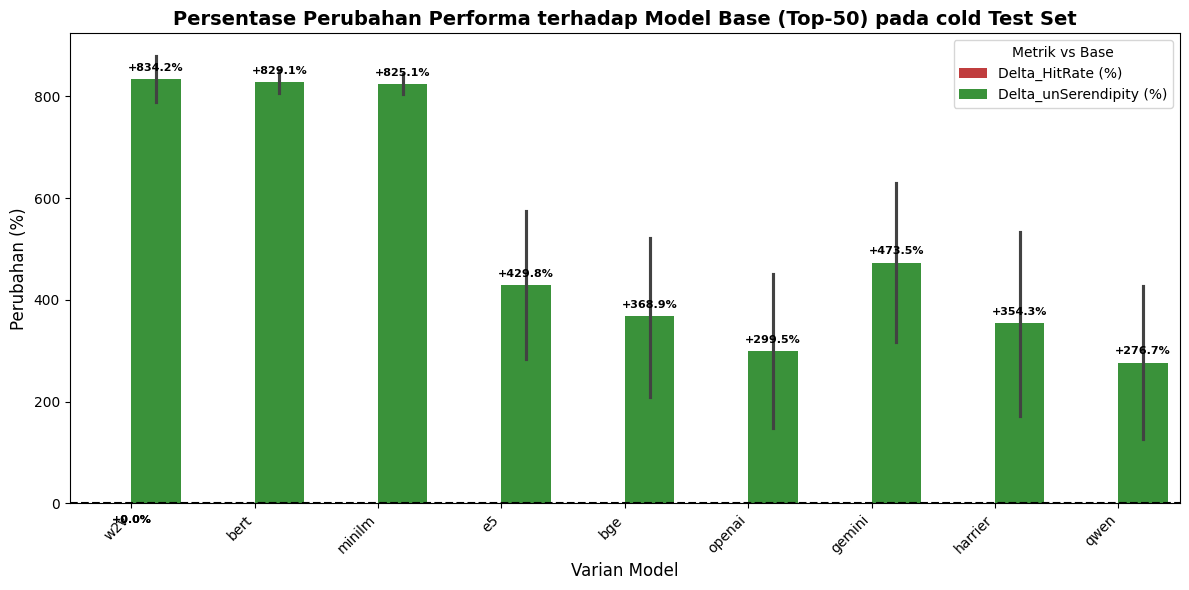

In [114]:
plot_delta_percentage(df_cold_users, k_val=50, user_type="cold")

# Save Model

In [ ]:
best_model = model_2_bert
best_weight = 'Aggressive'
import os
import pickle
import numpy as np

os.makedirs("saved_model", exist_ok=True)

best_model.save_weights("saved_model/best_sasrec_weights.weights.h5")
print("✅ Bobot model SASRec berhasil disimpan.")

item_embeddings = best_model.item_embedding.embeddings.numpy()
np.save("saved_model/item_embeddings.npy", item_embeddings)
print("✅ Matriks Embedding berhasil disimpan.")

sog_best_weights = sog_weight_scenarios[best_weight]

artifacts = {
    "sog_weights": sog_best_weights,
    "sequences_dict": sequences,
    "id_to_books": id_to_books,
    "books_to_id": books_to_id,
    "users_to_id": users_to_id,
    "id_to_users": id_to_users,
}

with open("saved_model/recsys_artifacts.pkl", "wb") as f:
    pickle.dump(artifacts, f)
print("✅ Bobot SOG dan Dictionary Riwayat berhasil disimpan.")